In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #绘图工具
import seaborn as sns
import warnings
import time
import torch
warnings.filterwarnings("ignore")
#设置jupyter显示多行结果
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all' #默认为'last'
# #显示所有列
pd.set_option('display.max_columns', None) #原来中间会有部分列的显示被省略
# #显示所有行
# pd.set_option('display.max_rows', None)
#设置value的显示长度为100，默认为50
pd.set_option('max_colwidth',100)
plt.rcParams['font.sans-serif'] = ['SimHei']  #显示中文
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号

In [2]:
rootpath = "./KuaiRec 2.0/"
threshold = 2

In [3]:
big_matrix = pd.read_csv(rootpath + "data/small_matrix.csv").dropna()
#排序按照time
big_matrix = big_matrix.sort_values(by = "time").reset_index(drop = True)
big_matrix 

,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio
0,6190,9559,29789,15034,2020-07-04 02:23:26.06,20200705.0,1.593801e+09,1.981442
1,6190,1926,5410,6867,2020-07-04 02:29:21.683,20200705.0,1.593801e+09,0.787826
2,6190,9553,10258,10634,2020-07-04 04:03:18.888,20200705.0,1.593807e+09,0.964642
3,6190,9530,1228,10960,2020-07-04 04:03:53.725,20200705.0,1.593807e+09,0.112044
4,6190,6760,1848,11934,2020-07-04 04:08:47.861,20200705.0,1.593807e+09,0.154852
...,...,...,...,...,...,...,...,...
4494573,4766,10291,4863,28352,2020-09-05 23:52:40.419,20200905.0,1.599321e+09,0.171522
4494574,6682,3151,5948,9706,2020-09-05 23:52:56.23,20200905.0,1.599321e+09,0.612817
4494575,6139,9112,4618,10234,2020-09-05 23:53:50.831,20200905.0,1.599321e+09,0.451241
4494576,5450,9162,7525,8638,2020-09-05 23:57:15.282,20200905.0,1.599321e+09,0.871151


In [4]:
big_matrix['time'] = pd.to_datetime(big_matrix['time'])

# 提取日期部分
big_matrix['date_from_time'] = pd.to_datetime(big_matrix['time']).dt.strftime('%Y%m%d').astype(int)
big_matrix['date_from_time'].unique() 

array([20200704, 20200705, 20200706, 20200707, 20200708, 20200709,
       20200710, 20200711, 20200712, 20200713, 20200714, 20200715,
       20200716, 20200717, 20200718, 20200719, 20200720, 20200721,
       20200722, 20200723, 20200724, 20200725, 20200726, 20200727,
       20200728, 20200729, 20200730, 20200731, 20200801, 20200802,
       20200803, 20200804, 20200805, 20200806, 20200807, 20200808,
       20200809, 20200810, 20200811, 20200812, 20200813, 20200814,
       20200815, 20200816, 20200817, 20200818, 20200819, 20200820,
       20200821, 20200822, 20200823, 20200824, 20200825, 20200826,
       20200827, 20200828, 20200829, 20200830, 20200831, 20200901,
       20200902, 20200903, 20200904, 20200905])

In [5]:
big_matrix["date"].unique()
# 日期是8 + 10 + 10

array([20200705., 20200706., 20200707., 20200708., 20200709., 20200710.,
       20200711., 20200712., 20200713., 20200714., 20200715., 20200716.,
       20200717., 20200718., 20200719., 20200720., 20200721., 20200722.,
       20200725., 20200723., 20200724., 20200726., 20200727., 20200728.,
       20200729., 20200730., 20200731., 20200802., 20200801., 20200803.,
       20200804., 20200805., 20200806., 20200807., 20200812., 20200811.,
       20200808., 20200809., 20200810., 20200813., 20200814., 20200815.,
       20200817., 20200816., 20200818., 20200819., 20200820., 20200821.,
       20200822., 20200823., 20200824., 20200825., 20200827., 20200826.,
       20200828., 20200829., 20200830., 20200831., 20200901., 20200903.,
       20200902., 20200904., 20200905.])

In [6]:
def get_period(row):
    if row<=20200722:
        return 1
    elif row<=20200815:
        return 2
    else:
        return 3
big_matrix["period"] = big_matrix["date_from_time"].apply(get_period)

In [7]:
big_matrix = big_matrix[big_matrix["period"]<=3]

In [8]:
user_date_interactions_count = big_matrix[["user_id", "video_id", "period"]].groupby(["user_id", "period"]).count()
user_date_interactions_count.columns = ["count"]
user_date_interactions_count = user_date_interactions_count.reset_index(drop=False)
user_date_interactions_count

# user_date_interactions_count=user_date_interactions_count[user_date_interactions_count["period"]<=2]

user_date_count = user_date_interactions_count[["user_id", "period"]].groupby(["user_id"]).count()
user_date_count.columns = ["period_count"]
# user_date_count = user_date_count.reset_index(drop=False)
user_date_count

user_date_count[user_date_count["period_count"]==1].shape[0]
user_date_count[user_date_count["period_count"]==2].shape[0]
user_date_count[user_date_count["period_count"]==3].shape[0]

,user_id,period,count
0,14,1,969
1,14,2,1672
2,14,3,593
3,19,1,1046
4,19,2,1546
...,...,...,...
4228,7159,2,1644
4229,7159,3,569
4230,7162,1,972
4231,7162,2,1656


,period_count
user_id,
14,3
19,3
21,3
23,3
24,3
...,...
7142,3
7147,3
7153,3


0

0

1411

In [9]:
item_date_interactions_count = big_matrix[["user_id", "video_id", "period"]].groupby(["video_id", "period"]).count()
item_date_interactions_count.columns = ["count"]
item_date_interactions_count = item_date_interactions_count.reset_index(drop=False)
item_date_interactions_count

# item_date_interactions_count=item_date_interactions_count[item_date_interactions_count["period"]<=2]

item_date_count = item_date_interactions_count[["video_id", "period"]].groupby(["video_id"]).count()
item_date_count.columns = ["period_count"]
# item_date_count = item_date_count.reset_index(drop=False)
item_date_count

item_date_count[item_date_count["period_count"]==1].shape[0]
item_date_count[item_date_count["period_count"]==2].shape[0]
item_date_count[item_date_count["period_count"]==3].shape[0]

,video_id,period,count
0,103,1,1191
1,103,2,58
2,109,1,1279
3,109,2,61
4,109,3,1
...,...,...,...
6723,10506,3,1368
6724,10519,3,1365
6725,10552,3,1364
6726,10589,3,1369


,period_count
video_id,
103,2
109,3
120,2
122,2
128,3
...,...
10506,1
10519,1
10552,1


469

2315

543

In [10]:
# 过滤留下2个period都有交互的用户 Item
# fliter_user_list = user_date_count[user_date_count["period_count"]==2].index.tolist()
# fliter_item_list = item_date_count[item_date_count["period_count"]==2].index.tolist()
# fliter_data = big_matrix[big_matrix["user_id"].isin(fliter_user_list)].reset_index(drop=True)
# fliter_data = fliter_data[fliter_data["video_id"].isin(fliter_item_list)].reset_index(drop=True)
fliter_data = big_matrix
fliter_data.sort_values(by="time", inplace=True, ascending=True) # 按照时间排序
fliter_data = fliter_data.reset_index(drop=True)
fliter_data
len(fliter_data["user_id"].unique())
len(fliter_data["video_id"].unique())


date_interactions_count = fliter_data[["user_id", "date_from_time"]].groupby(["date_from_time"]).count()
date_interactions_count.columns = ["count"]
date_interactions_count

#fliter_data 现在是两个时期都出现的用户 和 两个时期都出现的物品的 交互数据

,user_id,video_id,play_duration,video_duration,time,date,timestamp,watch_ratio,date_from_time,period
0,6190,9559,29789,15034,2020-07-04 02:23:26.060,20200705.0,1.593801e+09,1.981442,20200704,1
1,6190,1926,5410,6867,2020-07-04 02:29:21.683,20200705.0,1.593801e+09,0.787826,20200704,1
2,6190,9553,10258,10634,2020-07-04 04:03:18.888,20200705.0,1.593807e+09,0.964642,20200704,1
3,6190,9530,1228,10960,2020-07-04 04:03:53.725,20200705.0,1.593807e+09,0.112044,20200704,1
4,6190,6760,1848,11934,2020-07-04 04:08:47.861,20200705.0,1.593807e+09,0.154852,20200704,1
...,...,...,...,...,...,...,...,...,...,...
4494573,4766,10291,4863,28352,2020-09-05 23:52:40.419,20200905.0,1.599321e+09,0.171522,20200905,3
4494574,6682,3151,5948,9706,2020-09-05 23:52:56.230,20200905.0,1.599321e+09,0.612817,20200905,3
4494575,6139,9112,4618,10234,2020-09-05 23:53:50.831,20200905.0,1.599321e+09,0.451241,20200905,3
4494576,5450,9162,7525,8638,2020-09-05 23:57:15.282,20200905.0,1.599321e+09,0.871151,20200905,3


1411

3327

,count
date_from_time,
20200704,10
20200705,28328
20200706,38303
20200707,51899
20200708,56808
...,...
20200901,20259
20200902,14739
20200903,10241


In [11]:
fliter_data["label"] = fliter_data["watch_ratio"].apply(lambda x: 1 if x > threshold else 0)
fliter_data = fliter_data[["label","user_id","video_id","date","date_from_time","time", "watch_ratio","period"]]
fliter_data
#fliter_data 将交互数据中观看时长大于阈值的一批数据设置为label = 1

,label,user_id,video_id,date,date_from_time,time,watch_ratio,period
0,0,6190,9559,20200705.0,20200704,2020-07-04 02:23:26.060,1.981442,1
1,0,6190,1926,20200705.0,20200704,2020-07-04 02:29:21.683,0.787826,1
2,0,6190,9553,20200705.0,20200704,2020-07-04 04:03:18.888,0.964642,1
3,0,6190,9530,20200705.0,20200704,2020-07-04 04:03:53.725,0.112044,1
4,0,6190,6760,20200705.0,20200704,2020-07-04 04:08:47.861,0.154852,1
...,...,...,...,...,...,...,...,...
4494573,0,4766,10291,20200905.0,20200905,2020-09-05 23:52:40.419,0.171522,3
4494574,0,6682,3151,20200905.0,20200905,2020-09-05 23:52:56.230,0.612817,3
4494575,0,6139,9112,20200905.0,20200905,2020-09-05 23:53:50.831,0.451241,3
4494576,0,5450,9162,20200905.0,20200905,2020-09-05 23:57:15.282,0.871151,3


In [12]:
len(fliter_data[fliter_data["label"]==1])/len(fliter_data)

0.04662617936544877

In [13]:
from datetime import datetime, timedelta, time
morning_start = time(8,0,0)
noon_start = time(11,30,0)
afternoon_start = time(14,0,0)
night_start = time(17,30,0)
rest_start = time(22,0,0)

# fliter_data['dateymd'] = pd.to_datetime(fliter_data['date'], format='%Y%m%d')
# fliter_data['dayofweek'] = fliter_data['dateymd'].apply(lambda x: x.weekday())
# fliter_data["dayofweek_str"] = fliter_data["dayofweek"].apply(lambda x: "Mon" if x == 0 else "Tue" if x==1 else "Wed" if x==2 else "Thu" if x==3 else "Fri" if x==4 else "Sat" if x==5 else "Sun" )

# fliter_data['time'] = pd.to_datetime(fliter_data['time'])
fliter_data_time = fliter_data.time.dt.time 
fliter_data["blockofday"] = fliter_data_time.apply(lambda x: "morning" if x >= morning_start and x < noon_start else "noon" if x >= noon_start and x < afternoon_start else "afternoon" if x >= afternoon_start and x < night_start else "night" if x >= night_start and x < rest_start else "rest")
# #day of week
fliter_data["dayofweek"] = fliter_data.time.dt.weekday 
fliter_data["dayofweek_str"] = fliter_data["dayofweek"].apply(lambda x: "Mon" if x == 0 else "Tue" if x==1 else "Wed" if x==2 else "Thu" if x==3 else "Fri" if x==4 else "Sat" if x==5 else "Sun" )
# #is weekday?
fliter_data["isweekday"] = fliter_data['dayofweek'].apply(lambda x: 1 if x <= 4 else 0)
fliter_data

,label,user_id,video_id,date,date_from_time,time,watch_ratio,period,blockofday,dayofweek,dayofweek_str,isweekday
0,0,6190,9559,20200705.0,20200704,2020-07-04 02:23:26.060,1.981442,1,rest,5,Sat,0
1,0,6190,1926,20200705.0,20200704,2020-07-04 02:29:21.683,0.787826,1,rest,5,Sat,0
2,0,6190,9553,20200705.0,20200704,2020-07-04 04:03:18.888,0.964642,1,rest,5,Sat,0
3,0,6190,9530,20200705.0,20200704,2020-07-04 04:03:53.725,0.112044,1,rest,5,Sat,0
4,0,6190,6760,20200705.0,20200704,2020-07-04 04:08:47.861,0.154852,1,rest,5,Sat,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4494573,0,4766,10291,20200905.0,20200905,2020-09-05 23:52:40.419,0.171522,3,rest,5,Sat,0
4494574,0,6682,3151,20200905.0,20200905,2020-09-05 23:52:56.230,0.612817,3,rest,5,Sat,0
4494575,0,6139,9112,20200905.0,20200905,2020-09-05 23:53:50.831,0.451241,3,rest,5,Sat,0
4494576,0,5450,9162,20200905.0,20200905,2020-09-05 23:57:15.282,0.871151,3,rest,5,Sat,0


In [14]:
fliter_data_positive = fliter_data[fliter_data["label"]==1]
fliter_data_positive

,label,user_id,video_id,date,date_from_time,time,watch_ratio,period,blockofday,dayofweek,dayofweek_str,isweekday
7,1,6190,6752,20200705.0,20200704,2020-07-04 06:50:30.434,3.185472,1,rest,5,Sat,0
28,1,1457,1963,20200705.0,20200705,2020-07-05 00:03:17.081,3.087278,1,rest,6,Sun,0
32,1,2653,148,20200705.0,20200705,2020-07-05 00:03:33.047,2.005439,1,rest,6,Sun,0
48,1,1623,8234,20200705.0,20200705,2020-07-05 00:04:53.517,2.975727,1,rest,6,Sun,0
52,1,5624,1963,20200705.0,20200705,2020-07-05 00:05:00.404,6.190104,1,rest,6,Sun,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4494384,1,6567,4728,20200905.0,20200905,2020-09-05 20:16:13.228,2.905795,3,night,5,Sat,0
4494416,1,1886,4649,20200905.0,20200905,2020-09-05 20:40:05.863,5.664868,3,night,5,Sat,0
4494544,1,3246,4758,20200905.0,20200905,2020-09-05 22:55:18.107,2.537899,3,rest,5,Sat,0
4494546,1,4766,3183,20200905.0,20200905,2020-09-05 22:59:22.553,2.561192,3,rest,5,Sat,0


In [15]:
fliter_data_negtive = fliter_data[fliter_data["label"]==0]
fliter_data_negtive

,label,user_id,video_id,date,date_from_time,time,watch_ratio,period,blockofday,dayofweek,dayofweek_str,isweekday
0,0,6190,9559,20200705.0,20200704,2020-07-04 02:23:26.060,1.981442,1,rest,5,Sat,0
1,0,6190,1926,20200705.0,20200704,2020-07-04 02:29:21.683,0.787826,1,rest,5,Sat,0
2,0,6190,9553,20200705.0,20200704,2020-07-04 04:03:18.888,0.964642,1,rest,5,Sat,0
3,0,6190,9530,20200705.0,20200704,2020-07-04 04:03:53.725,0.112044,1,rest,5,Sat,0
4,0,6190,6760,20200705.0,20200704,2020-07-04 04:08:47.861,0.154852,1,rest,5,Sat,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4494573,0,4766,10291,20200905.0,20200905,2020-09-05 23:52:40.419,0.171522,3,rest,5,Sat,0
4494574,0,6682,3151,20200905.0,20200905,2020-09-05 23:52:56.230,0.612817,3,rest,5,Sat,0
4494575,0,6139,9112,20200905.0,20200905,2020-09-05 23:53:50.831,0.451241,3,rest,5,Sat,0
4494576,0,5450,9162,20200905.0,20200905,2020-09-05 23:57:15.282,0.871151,3,rest,5,Sat,0


In [16]:
fliter_data_count = fliter_data_positive[["user_id", "date_from_time"]].groupby(["date_from_time"]).count()
fliter_data_count.columns = ["count"]
fliter_data_count

,count
date_from_time,
20200704,1
20200705,1877
20200706,2323
20200707,3014
20200708,3380
...,...
20200901,1521
20200902,724
20200903,431


In [18]:
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype
import random
# 按照'dayofweek_str','blockofday'分组，并从每组中随机采样2000条记录
cat_dtype1 = CategoricalDtype(categories=["Mon", "Tue", "Wed", "Thu","Fri","Sat","Sun"], ordered=True)
cat_dtype2 = CategoricalDtype(categories=["morning", "noon", "afternoon", "night","rest"], ordered=True)
build_data_list = []
for i in range(0,10):
    random.seed(i*68) # 指定随机种子为123
    grouped = fliter_data_positive.groupby(['date_from_time','blockofday'], group_keys=False).apply(lambda x: x if len(x) > 50 else None).dropna()
    grouped = grouped.groupby(['date_from_time','blockofday'], group_keys=False).apply(lambda x: x.sample(n=1000, replace=False) if len(x) > 1500 else x.sample(n=len(x))).dropna()
    # grouped = grouped.sort_values("dayofweek_str")
    # grouped = fliter_data_positive.groupby(['date_from_time', 'blockofday'], group_keys=False).apply(lambda x: x.drop_duplicates(subset=['user_id']).sample(n=500))
    # grouped["dayofweek_str"] = grouped["dayofweek_str"].astype(cat_dtype1)
    # grouped["blockofday"] = grouped["blockofday"].astype(cat_dtype2)
    # grouped = grouped.sort_values(by=["dayofweek_str","blockofday"])
    grouped = grouped.sort_values("time").reset_index(drop=True)

    grouped_oneweek = grouped[grouped["date_from_time"] >=20200810] 
    grouped_oneweek = grouped_oneweek[grouped["date_from_time"] <=20200816] 
    grouped_oneweek["week"] = i
    build_data_list.append(grouped_oneweek)

build_data = pd.concat(build_data_list, ignore_index=True)
build_data.sort_values(["week","time"], inplace=True)
build_data.head(30)

# # 将所有组别的记录按顺序排列，并重复n次
# n = 10 # 重复次数相当于几周
# build_data = pd.concat([grouped]*n, ignore_index=True)
# build_data

,label,user_id,video_id,date,date_from_time,time,watch_ratio,period,blockofday,dayofweek,dayofweek_str,isweekday,week
0,1,1623,4592,20200810.0,20200810,2020-08-10 00:02:51.739,2.068251,2,rest,0,Mon,1,0
1,1,73,4605,20200810.0,20200810,2020-08-10 00:03:55.572,5.077739,2,rest,0,Mon,1,0
2,1,7054,551,20200810.0,20200810,2020-08-10 00:04:04.525,3.140656,2,rest,0,Mon,1,0
3,1,6301,1121,20200810.0,20200810,2020-08-10 00:04:21.363,2.035347,2,rest,0,Mon,1,0
4,1,5431,1205,20200810.0,20200810,2020-08-10 00:04:42.153,4.164353,2,rest,0,Mon,1,0
5,1,5515,4605,20200810.0,20200810,2020-08-10 00:06:19.526,2.513163,2,rest,0,Mon,1,0
6,1,4499,4592,20200810.0,20200810,2020-08-10 00:07:14.555,2.247803,2,rest,0,Mon,1,0
7,1,234,4531,20200810.0,20200810,2020-08-10 00:07:23.541,2.171651,2,rest,0,Mon,1,0
8,1,2094,4605,20200810.0,20200810,2020-08-10 00:08:06.719,5.490145,2,rest,0,Mon,1,0
9,1,5515,4443,20200810.0,20200810,2020-08-10 00:08:07.210,2.575808,2,rest,0,Mon,1,0


In [19]:
unique_user_ids = build_data['user_id'].nunique()
unique_user_ids

1347

In [23]:
build_keycolumn = build_data[['user_id','video_id','date','date_from_time','dayofweek','blockofday','dayofweek_str','isweekday',"week"]]
build_keycolumn

,user_id,video_id,date,date_from_time,dayofweek,blockofday,dayofweek_str,isweekday,week
0,1623,4592,20200810.0,20200810,0,rest,Mon,1,0
1,73,4605,20200810.0,20200810,0,rest,Mon,1,0
2,7054,551,20200810.0,20200810,0,rest,Mon,1,0
3,6301,1121,20200810.0,20200810,0,rest,Mon,1,0
4,5431,1205,20200810.0,20200810,0,rest,Mon,1,0
...,...,...,...,...,...,...,...,...,...
220915,6190,10382,20200816.0,20200816,6,rest,Sun,0,9
220916,1178,6261,20200816.0,20200816,6,rest,Sun,0,9
220917,55,1299,20200816.0,20200816,6,rest,Sun,0,9
220918,4924,7710,20200816.0,20200816,6,rest,Sun,0,9


### 测试一下周期性

In [24]:
item_daily_features = pd.read_csv(rootpath + "data/item_daily_features.csv")
item_daily_features

,video_id,date,author_id,video_type,upload_dt,upload_type,visible_status,video_duration,video_width,video_height,music_id,video_tag_id,video_tag_name,show_cnt,show_user_num,play_cnt,play_user_num,play_duration,complete_play_cnt,complete_play_user_num,valid_play_cnt,valid_play_user_num,long_time_play_cnt,long_time_play_user_num,short_time_play_cnt,short_time_play_user_num,play_progress,comment_stay_duration,like_cnt,like_user_num,click_like_cnt,double_click_cnt,cancel_like_cnt,cancel_like_user_num,comment_cnt,comment_user_num,direct_comment_cnt,reply_comment_cnt,delete_comment_cnt,delete_comment_user_num,comment_like_cnt,comment_like_user_num,follow_cnt,follow_user_num,cancel_follow_cnt,cancel_follow_user_num,share_cnt,share_user_num,download_cnt,download_user_num,report_cnt,report_user_num,reduce_similar_cnt,reduce_similar_user_num,collect_cnt,collect_user_num,cancel_collect_cnt,cancel_collect_user_num
0,0,20200705,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,3350323409,841,建筑,14665,11372,10141,7485,88729488,5657,4834,5503,4775,5503,4775,1939,1481,0.799860,6629173,573,569,315,257,87,85,11,11,8,3,0,0,112,61,284,284,0,0,2,2,8,8,0,0,3,3,NaN,NaN,NaN,NaN
1,0,20200706,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,3350323409,841,建筑,10883,8513,7321,5490,64264607,4162,3522,4039,3468,4039,3468,1340,1040,0.805253,3997498,302,301,159,142,47,47,7,7,6,1,0,0,60,32,201,200,0,0,1,1,2,2,0,0,5,5,NaN,NaN,NaN,NaN
2,0,20200707,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,3350323409,841,建筑,7842,6281,4757,3724,41338741,2734,2403,2640,2376,2640,2376,866,683,0.808821,3314323,205,205,121,84,52,50,4,3,3,1,0,0,59,26,131,131,0,0,1,1,2,2,0,0,0,0,NaN,NaN,NaN,NaN
3,0,20200708,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,3350323409,841,建筑,8916,7229,5172,3961,45281254,2950,2525,2865,2498,2865,2498,977,765,0.801680,4235579,297,293,178,119,60,59,4,4,2,2,0,0,91,46,179,179,0,0,2,2,3,3,0,0,3,3,NaN,NaN,NaN,NaN
4,0,20200709,3309,NORMAL,2020-03-30,ShortImport,public,5966.0,720,1280,3350323409,841,建筑,8502,6658,5392,3946,46952744,3058,2566,2946,2533,2945,2532,1046,752,0.805359,3862095,307,305,166,141,57,56,5,2,0,5,0,0,76,47,186,186,0,0,0,0,2,2,2,1,1,1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343336,10723,20200905,236,NORMAL,2020-09-05,ShortImport,public,4833.0,720,1280,4428603493,11,生活,277,173,214,157,1681908,117,106,114,104,114,104,83,66,0.596591,337534,24,24,6,18,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0
343337,10724,20200905,5271,NORMAL,2020-09-05,LongImport,public,54720.0,720,1280,1090207430,2,音乐,1100,1017,965,856,56090732,535,523,754,721,657,637,113,99,0.574591,1249884,264,261,224,39,14,13,29,27,29,0,0,0,3,3,8,8,0,0,1,1,1,1,0,0,0,0,0.0,0.0,0.0,0.0
343338,10725,20200905,1924,NORMAL,2020-09-05,ShortImport,public,15800.0,576,1024,4429406509,15,才艺,16996,16345,15487,14672,323787284,8149,8015,9317,9171,7949,7871,4342,4139,0.577613,1963153,851,845,574,275,19,19,36,28,34,2,0,0,1,1,12,12,0,0,3,2,5,5,0,0,4,4,0.0,0.0,0.0,0.0
343339,10726,20200905,7604,NORMAL,2020-09-05,ShortImport,public,5132.0,528,960,68154,19,情感,7644,7568,7859,7480,128835301,5480,5395,5382,5319,5382,5319,1648,1580,0.818123,192695,44,44,18,25,1,1,0,0,0,0,0,0,0,0,2,2,0,0,1,1,2,2,0,0,1,1,0.0,0.0,0.0,0.0


#####  将item设置为类别，这一步编码类别

##### itemtag 的key 是video id 和 date 

In [25]:
item_tag = item_daily_features[['video_id','date','video_tag_name']].drop_duplicates()#,'date'

# 将 NaN 值替换为空字符串
item_tag = item_tag.dropna()
item_tag

# 按照 video_id 分组，并拼接 video_tag_name 列
# grouped_item_tag = item_tag.groupby('video_id').agg({'video_tag_name': lambda x: ' '.join(x)}).reset_index()#'date': 'first', 
# grouped_item_tag


,video_id,date,video_tag_name
0,0,20200705,建筑
1,0,20200706,建筑
2,0,20200707,建筑
3,0,20200708,建筑
4,0,20200709,建筑
...,...,...,...
343336,10723,20200905,生活
343337,10724,20200905,音乐
343338,10725,20200905,才艺
343339,10726,20200905,情感


##### category 是类别id  和 类别名字的 表

In [26]:
unique_tags = item_tag['video_tag_name'].unique().tolist()
len(unique_tags)
category = pd.DataFrame({'video_tag_name': unique_tags})
category = category.reset_index(drop=True)
#将index转换为video_tag_id
category['video_tag_id'] = category.index
category

529

,video_tag_name,video_tag_id
0,建筑,0
1,颜值,1
2,高新数码,2
3,生活,3
4,搞笑,4
...,...,...
524,植物大战僵尸2,524
525,抓娃娃,525
526,刀具,526
527,化妆品,527


##### 构造类别特征向量


In [45]:
import torch
import re
from transformers import BertTokenizer, BertModel

# # 加载预训练的中文BERT模型
model_name = 'bert-base-chinese'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

# 定义要编码的中文tag
category_embedding = []

textlist = category['video_tag_name'].tolist()
for i, text in enumerate(textlist):
    # 将tag转换为tokens，并添加特殊标记
    clean_text = re.sub(r'[^\w\s]','',text)
    tag_tokens = tokenizer.encode('[CLS]' + clean_text + '[SEP]')
    # 将tokens转换为PyTorch张量
    tag_tensor = torch.tensor(tag_tokens)
    # 使用BERT模型生成输出向量
    with torch.no_grad():
        outputs = model(tag_tensor.unsqueeze(0))
        tag_vector = outputs[0][0][1:-1].mean(dim=0).numpy()
    category_embedding.append(tag_vector)
    
# # 打印中文tag的词向量
category_df = pd.DataFrame(category_embedding)
category_df

Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639,640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767
0,-0.717634,0.504071,-0.379064,-0.346465,0.893738,-0.274025,-0.271350,0.278183,-0.665067,0.150430,-0.215633,0.015296,0.791867,-0.055935,1.749482,-0.175547,0.559582,-1.282980,0.281495,0.135933,-0.433427,0.090514,-0.199315,-0.018171,-0.027250,0.655015,-0.072232,-0.493546,0.407989,0.222000,-0.076948,-0.955090,-0.970402,0.616182,1.152355,-0.834686,-0.475307,0.195923,0.010804,-0.836451,-0.175673,0.270494,-0.272420,1.418764,0.503426,-0.075818,0.324402,0.742293,-0.453479,0.848448,0.911400,6.750812,1.313839,0.518711,-0.258276,0.459496,1.288066,0.101364,0.322570,-0.306099,-0.626307,-1.218500,1.086352,1.033015,-0.248635,-0.487207,0.214298,0.379172,-1.301846,-0.623906,-0.270697,-0.547131,0.596331,1.040146,-0.879129,-0.139807,-0.237626,0.289784,-0.898418,-0.035758,0.506846,0.348146,0.044891,-0.110958,-0.511576,-0.782419,-0.508303,-2.811272,0.967884,0.632870,-0.125250,-1.364994,0.156631,-0.068485,0.524956,0.501504,0.467123,0.423729,-0.279556,-1.178138,0.027664,1.177271,-0.262371,-0.345937,-1.001834,0.342424,-0.751943,-0.631528,-0.0610

##### 降维度

In [46]:
from sklearn.decomposition import PCA
n_components  = 30
pca = PCA(n_components=n_components)
item_df_for_pca = category_df
pca.fit(item_df_for_pca)
item_pca = pca.transform(item_df_for_pca)
item_pca

PCA(n_components=30)

array([[-3.7517495 , -4.0608826 , -3.1482458 , ..., -0.54250824,
        -0.23271106, -0.55845433],
       [-2.5191412 ,  8.220833  , -1.4838955 , ..., -0.18556038,
        -0.5397409 , -0.92851484],
       [ 5.6833014 , -0.2276358 , -0.54873407, ...,  1.0474259 ,
        -0.56398493, -2.4985375 ],
       ...,
       [-0.9548761 ,  2.7784944 ,  1.2730498 , ..., -0.51821166,
        -0.13658342,  1.965523  ],
       [ 2.736781  ,  0.6720917 , -3.8047335 , ...,  0.02688035,
        -2.1770031 , -0.39781955],
       [ 1.9618173 ,  0.7100472 , -1.7972215 , ...,  0.33768722,
        -1.568516  ,  0.6479695 ]], dtype=float32)

##### 降维度后的数据 category_vector 包含类别的id 和向量

In [48]:
item_pca_df = pd.DataFrame(item_pca)
index_item_pca_df = item_pca_df.reset_index()#.rename(columns={"index":"timeId"})
index_item_pca_df.columns = ["video_tag_id"] + ["i"+str(i) for i in range(30)]
category_vector = index_item_pca_df
category_vector

,video_tag_id,i0,i1,i2,i3,i4,i5,i6,i7,i8,i9,i10,i11,i12,i13,i14,i15,i16,i17,i18,i19,i20,i21,i22,i23,i24,i25,i26,i27,i28,i29
0,0,-3.751750,-4.060883,-3.148246,1.898667,-0.863591,-1.632046,0.218840,0.003671,-1.815074,1.432105,0.945011,0.477057,-1.475786,-1.042436,0.683730,-0.513672,-0.828150,0.052979,-1.333344,-1.829349,0.301675,-0.146623,1.542337,-0.523542,1.468130,-0.747072,-0.918082,-0.542508,-0.232711,-0.558454
1,1,-2.519141,8.220833,-1.483896,0.309901,0.372705,0.883088,1.071568,-0.712757,-0.683147,1.635796,0.635908,-1.119267,-0.838164,0.483403,-0.376738,-0.442072,-0.451612,0.357249,0.430362,-0.616379,0.661696,-1.637146,-0.644614,-0.442051,0.696950,1.380378,-0.190840,-0.185560,-0.539741,-0.928515
2,2,5.683301,-0.227636,-0.548734,-0.301585,0.431304,-1.668159,0.956823,-0.441986,0.399442,-1.819067,1.104596,-1.462506,1.020609,-1.193484,0.011340,1.506287,1.004507,1.366102,-0.246946,-0.331734,0.101292,-1.103615,-0.904059,-0.562437,0.115188,0.599019,0.089186,1.047426,-0.563985,-2.498538
3,3,-3.610892,0.716920,-2.822246,-0.452360,0.764910,0.615588,-0.402003,-0.695142,1.245770,0.276246,-0.409190,-0.179832,0.080418,0.933675,0.830585,-1.037802,-0.225668,0.056322,0.387449,0.169774,0.220172,-1.260943,0.450574,0.144471,0.136724,-0.479391,0.794468,0.118371,-0.886077,-0.527522
4,4,-2.542527,1.452903,-0.778703,-1.732270,-0.460347,2.231805,0.064268,1.598982,0.006308,0.175515,-3.391297,-1.281781,-0.976416,-0.000142,0.689165,0.397080,1.166220,1.174649,1.608571,-0.153433,0.683092,0.144329,0.165617,-0.317819,-0.273122,-0.613054,1.334016,0.325726,0.475271,-0.101451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524,524,9.452761,1.692919,0.706501,0.495442,3.354180,1.377850,1.888088,-0.422623,0.379435,-1.484819,-0.306202,-0.920585,0.407442,-0.346151,0.466720,-0.812865,3.293260,0.000854,-0.795625,-1.381088,2.761954,-2.053529,-0.967306,-0.888242,0.065572,-1.386738,-0.161339,-0.179599,-2.167183,1.740360
525,525,-0.068013,-4.294202,1.377785,-1.815625,-0.247202,1.163444,-0.459599,1.340344,0.085755,0.341608,-2.711247,-1.229476,1.807736,0.651989,1.362352,0.479552,3.229243,-1.271039,1.908828,-0.927424,-0.808875,1.690102,1.205514,-0.474858,0.400089,-0.246224,0.225307,-0.629328,-1.300537,0.299768
526,526,-0.954876,2.778494,1.273050,0.273281,-2.225716,-1.153578,-1.409231,-1.477885,-1.170996,-1.301912,0.026361,-0.392418,2.106463,-0.623838,0.224005,-0.862466,-0.331836,-0.668303,-1.140744,-0.344225,-0.692253,1.066811,-1.190446,1.446923,-0.013249,1.219939,0.930103,-0.518212,-0.136583,1.965523
527,527,2.736781,0.672092,-3.804734,-0.685422,1.052319,-2.285467,-3.593228,-1.417887,1.472511,1.771213,-0.171684,-1.546009,0.734650,-0.150407,-1.126306,-0.044302,0.862183,-0.035303,-0.457773,-0.168683,0.780231,0.566418,-1.126352,-0.648831,0.375125,0.243925,-0.551884,0.026880,-2.177003,-0.397820


##### 存起来类别特征

In [54]:
category_vector.to_csv("./cat_feature_pca.csv", sep=" ", index=False)

In [28]:
mergedata = pd.merge(build_keycolumn, item_tag, on=['video_id','date'], how='left')
known_data = mergedata[(mergedata["video_tag_name"] != '清晰')&(mergedata["video_tag_name"] != '正面') & (mergedata["video_tag_name"] != 'UNKNOWN') & (mergedata["video_tag_name"] != '侧面')  ]
# known_data[known_data["video_tag_name"] == '电影黑条']
known_data = known_data.dropna()
known_data
grouped = known_data.groupby('video_tag_name').size().sort_values(ascending=False)
grouped.head(50)

,user_id,video_id,date,date_from_time,dayofweek,blockofday,dayofweek_str,isweekday,week,video_tag_name
0,1623,4592,20200810.0,20200810,0,rest,Mon,1,0,道路
2,7054,551,20200810.0,20200810,0,rest,Mon,1,0,截图
3,6301,1121,20200810.0,20200810,0,rest,Mon,1,0,自拍脸
4,5431,1205,20200810.0,20200810,0,rest,Mon,1,0,听书
6,4499,4592,20200810.0,20200810,0,rest,Mon,1,0,道路
...,...,...,...,...,...,...,...,...,...,...
220914,1257,10206,20200816.0,20200816,6,rest,Sun,0,9,猫
220915,6190,10382,20200816.0,20200816,6,rest,Sun,0,9,农村
220917,55,1299,20200816.0,20200816,6,rest,Sun,0,9,旅游景点
220918,4924,7710,20200816.0,20200816,6,rest,Sun,0,9,婴儿


video_tag_name
篮球_篮球场     8130
猫          7250
电影黑条       7190
明星         5660
自拍脸        5470
轮滑         5320
舞蹈         4720
旅游景点       4220
自然场景       4090
动漫         3420
天空         3400
女青年        2960
走路         2640
书法         2520
截图         2500
狗          2480
卖鞋         2470
化妆         2460
户外         2360
农村         2170
头巾_帽子      2090
人-女        2090
少男         1800
熊猫         1770
穿衣秀        1730
女-半身-清纯    1720
海边_沙滩      1700
绘画         1680
直播截屏       1670
背面         1650
影视作品       1620
人群聚集       1570
男青年        1540
自由旅行       1520
少女         1480
穿戴         1470
听书         1390
军训         1370
镜子         1290
减肥         1270
健身         1270
女孩         1200
球类运动       1200
温馨         1200
室内         1190
泳池         1160
山水风景       1110
女-美腿       1090
法律知识       1050
跳舞         1020
dtype: int64

In [29]:
known_data = pd.merge(known_data, category, on=['video_tag_name'], how='left')
known_data

,user_id,video_id,date,date_from_time,dayofweek,blockofday,dayofweek_str,isweekday,week,video_tag_name,video_tag_id
0,1623,4592,20200810.0,20200810,0,rest,Mon,1,0,道路,310
1,7054,551,20200810.0,20200810,0,rest,Mon,1,0,截图,18
2,6301,1121,20200810.0,20200810,0,rest,Mon,1,0,自拍脸,16
3,5431,1205,20200810.0,20200810,0,rest,Mon,1,0,听书,43
4,4499,4592,20200810.0,20200810,0,rest,Mon,1,0,道路,310
...,...,...,...,...,...,...,...,...,...,...,...
164075,1257,10206,20200816.0,20200816,6,rest,Sun,0,9,猫,87
164076,6190,10382,20200816.0,20200816,6,rest,Sun,0,9,农村,204
164077,55,1299,20200816.0,20200816,6,rest,Sun,0,9,旅游景点,75
164078,4924,7710,20200816.0,20200816,6,rest,Sun,0,9,婴儿,101


In [29]:
known_data.isna().any().any()

False

<AxesSubplot:xlabel='dayofweek,blockofday'>

Text(0.5, 0, '(dayofweek, blockofday)')

Text(0, 0.5, 'visit counts')

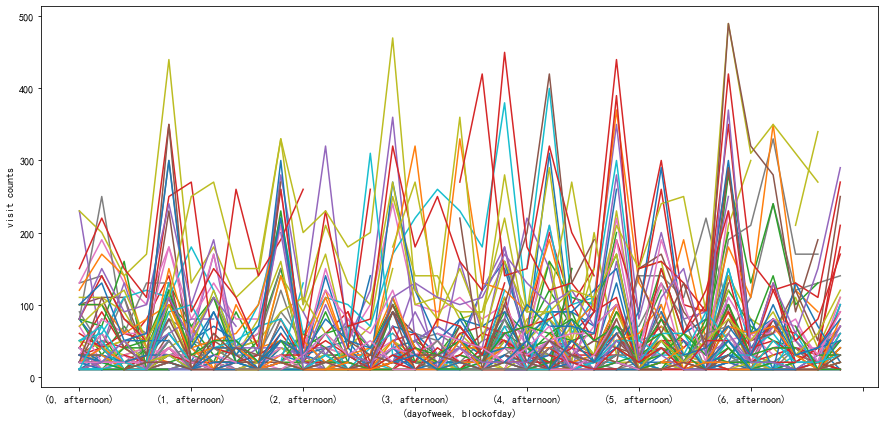

In [50]:
fig, ax = plt.subplots(figsize=(15,7))
# merged_data= merged_data[merged_data['category']!="Home (private)"]
pru = known_data.groupby([ 'dayofweek','blockofday','video_tag_name']).video_id.agg([len])
# pru['percent'] = pru.groupby(['dayofweek','blockofday'])['len'].apply(lambda x: x / float(x.sum()))
pru2 =pru.query('len > 0 and len<500')
# pru_sorted = pru2.sort_values(by='len')  # 按照len降序排列
# top5_categories = pru_sorted.index.get_level_values('venueCategory').unique()[:5]  # 取前5大的venueCategory

pru2.unstack().plot(ax=ax,legend=False)
# ax.legend(labels=pru_sorted.index.levels[2].tolist()[:5])
ax.set_xlabel('(dayofweek, blockofday)')
ax.set_ylabel('visit counts')

##### 词云检测


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
blockofday_dic = {0:'morning',1:'noon',2:'afternoon',3:'night',4:'rest'}
dayofweek_dic = {0:'Monday',1:'Tuesday',2:'Wednesday',3:'Thurthday',4:'Friday',5:'Saturday',6:'Sunday'}
isweekday_dic = {0:'weekend',1:'weekday'}

# 按照'dayofweek','blockofday'分组，并计算每个组别内的每个venueCategory出现的频率
word_data = known_data[['user_id','video_id','blockofday','dayofweek_str','date_from_time','video_tag_name','week']]

grouped = word_data.groupby(['week','dayofweek_str','video_tag_name']).size().reset_index(name='count')

#遍历 每个组别，生成词云
for (week,dayofweek_str), group in grouped.groupby(['week','dayofweek_str']):
# for dayofweek_str, group in grouped.groupby(['isweekday']):
    # 将每个组别的词频转化为字典类型
    print(week,dayofweek_str)#isweekday_dic[int(isweekday)]
    # print(dayofweek_str)
    word_freq = dict(zip(group['video_tag_name'], group['count']))
    
    # 设置词云参数
    wc = WordCloud(
        font_path='simsun.ttc',#'arial.ttf', # 英文字体库
        background_color='white',
        width=800,
        height=600,
        max_words=100000,
        # min_font_size=20,
        scale=1,
        # relative_scaling=0.5,
        repeat=False
    )
    
    # 生成词云图
    wc.generate_from_frequencies(word_freq)
    plt.figure(figsize=(5, 4))
    plt.imshow(wc)#interpolation='nearest'
    plt.axis('off')
    # plt.title(f"Day of Week: {dayofweek}, Block of Day: {blockofday}")
    # plt.savefig(f"{dayofweek}_{blockofday}.pdf", dpi=600, format='pdf', bbox_inches='tight')
    # plt.savefig("./KuaiRec 2.0/wordcloud/wc_{}_{}.svg".format(isweekday_dic[int(isweekday)],blockofday), format='svg', dpi=900, bbox_inches='tight', pad_inches=0)
    plt.show()


### 周期性测试完毕

##### 构造事件流

In [35]:
import pandas as pd
import numpy as np
import random
build_keycolumn = known_data[['user_id','video_tag_id','date','date_from_time','blockofday','dayofweek','dayofweek_str','isweekday','week']]
build_keycolumn
#armpool 负样本
# grouped = fliter_data_negtive.groupby(["date_from_time",'blockofday'])["video_id"].unique()

grouped = build_keycolumn.groupby(["isweekday"])["video_tag_id"].unique()

# grouped
# for group in grouped:
#     print(len(group))
# 按照["date","blockofday"]分组，并将每组中的video_id去重并生成一个set
# 对于每条数据，根据["date","blockofday"]对应的set中随机抽取25条
# def generate():
    
# build_keycolumn["armpool"] = build_keycolumn.apply(lambda x: ([x.video_id] + random.sample(grouped[(x["date_from_time"], x["blockofday"])].tolist(), 24)) if len(grouped[(x["date_from_time"], x["blockofday"])].tolist()) > 100 else None, axis=1).dropna()
# build_keycolumn.dropna(inplace=True)
def generate(x,grouped):
    #selected_tags = grouped[(x["date_from_time"], x["blockofday"])].tolist()
    selected_tags = grouped[(1-x["isweekday"])].tolist()
    # if len(selected_tags) > 100: 
    if x.video_tag_id in selected_tags:
        selected_tags.remove(x.video_tag_id)
    return [x.video_tag_id] + random.sample(selected_tags, 24)
    # else:
    #     return None
build_keycolumn["armpool"] = build_keycolumn.apply(lambda x: generate(x,grouped), axis=1)
build_keycolumn = build_keycolumn.dropna()
# build_keycolumn["armpool"] = build_keycolumn.apply(lambda x: ([x.video_id] + random.sample(grouped[(x["date_from_time"], x["blockofday"])].tolist(), 24)), axis=1)apply(lambda x: x if len(x) > 200 else None).dropna()
build_keycolumn

# build_keycolumn
# # sort_build_keycolumn

,user_id,video_tag_id,date,date_from_time,blockofday,dayofweek,dayofweek_str,isweekday,week
0,1623,310,20200810.0,20200810,rest,0,Mon,1,0
1,7054,18,20200810.0,20200810,rest,0,Mon,1,0
2,6301,16,20200810.0,20200810,rest,0,Mon,1,0
3,5431,43,20200810.0,20200810,rest,0,Mon,1,0
4,4499,310,20200810.0,20200810,rest,0,Mon,1,0
...,...,...,...,...,...,...,...,...,...
164075,1257,87,20200816.0,20200816,rest,6,Sun,0,9
164076,6190,204,20200816.0,20200816,rest,6,Sun,0,9
164077,55,75,20200816.0,20200816,rest,6,Sun,0,9
164078,4924,101,20200816.0,20200816,rest,6,Sun,0,9


,user_id,video_tag_id,date,date_from_time,blockofday,dayofweek,dayofweek_str,isweekday,week,armpool
0,1623,310,20200810.0,20200810,rest,0,Mon,1,0,"[310, 190, 238, 115, 289, 18, 9, 129, 4, 172, 24, 225, 106, 219, 436, 72, 421, 314, 89, 45, 391,..."
1,7054,18,20200810.0,20200810,rest,0,Mon,1,0,"[18, 119, 327, 85, 28, 204, 184, 140, 513, 234, 53, 56, 106, 357, 92, 105, 155, 178, 193, 91, 61..."
2,6301,16,20200810.0,20200810,rest,0,Mon,1,0,"[16, 331, 154, 175, 370, 421, 210, 62, 387, 90, 28, 269, 43, 23, 95, 238, 109, 108, 193, 119, 24..."
3,5431,43,20200810.0,20200810,rest,0,Mon,1,0,"[43, 147, 400, 328, 75, 243, 206, 48, 211, 50, 391, 28, 436, 33, 56, 219, 341, 119, 83, 42, 4, 4..."
4,4499,310,20200810.0,20200810,rest,0,Mon,1,0,"[310, 269, 175, 106, 100, 442, 312, 351, 87, 20, 54, 55, 163, 176, 178, 0, 339, 30, 45, 3, 70, 1..."
...,...,...,...,...,...,...,...,...,...,...
164075,1257,87,20200816.0,20200816,rest,6,Sun,0,9,"[87, 416, 0, 175, 24, 77, 47, 5, 139, 115, 393, 250, 450, 209, 199, 264, 279, 442, 364, 85, 358,..."
164076,6190,204,20200816.0,20200816,rest,6,Sun,0,9,"[204, 331, 206, 5, 205, 85, 169, 98, 92, 261, 292, 153, 106, 36, 357, 22, 33, 119, 217, 198, 227..."
164077,55,75,20200816.0,20200816,rest,6,Sun,0,9,"[75, 436, 206, 227, 70, 397, 272, 98, 93, 258, 393, 263, 499, 337, 38, 190, 163, 205, 102, 135, ..."
164078,4924,101,20200816.0,20200816,rest,6,Sun,0,9,"[101, 279, 8, 4, 41, 243, 39, 417, 420, 426, 24, 368, 9, 253, 92, 248, 114, 258, 91, 82, 295, 23..."


In [36]:
events = build_keycolumn[["user_id", "armpool", "dayofweek_str", "blockofday"]]
events

,user_id,armpool,dayofweek_str,blockofday
0,1623,"[310, 190, 238, 115, 289, 18, 9, 129, 4, 172, 24, 225, 106, 219, 436, 72, 421, 314, 89, 45, 391,...",Mon,rest
1,7054,"[18, 119, 327, 85, 28, 204, 184, 140, 513, 234, 53, 56, 106, 357, 92, 105, 155, 178, 193, 91, 61...",Mon,rest
2,6301,"[16, 331, 154, 175, 370, 421, 210, 62, 387, 90, 28, 269, 43, 23, 95, 238, 109, 108, 193, 119, 24...",Mon,rest
3,5431,"[43, 147, 400, 328, 75, 243, 206, 48, 211, 50, 391, 28, 436, 33, 56, 219, 341, 119, 83, 42, 4, 4...",Mon,rest
4,4499,"[310, 269, 175, 106, 100, 442, 312, 351, 87, 20, 54, 55, 163, 176, 178, 0, 339, 30, 45, 3, 70, 1...",Mon,rest
...,...,...,...,...
164075,1257,"[87, 416, 0, 175, 24, 77, 47, 5, 139, 115, 393, 250, 450, 209, 199, 264, 279, 442, 364, 85, 358,...",Sun,rest
164076,6190,"[204, 331, 206, 5, 205, 85, 169, 98, 92, 261, 292, 153, 106, 36, 357, 22, 33, 119, 217, 198, 227...",Sun,rest
164077,55,"[75, 436, 206, 227, 70, 397, 272, 98, 93, 258, 393, 263, 499, 337, 38, 190, 163, 205, 102, 135, ...",Sun,rest
164078,4924,"[101, 279, 8, 4, 41, 243, 39, 417, 420, 426, 24, 368, 9, 253, 92, 248, 114, 258, 91, 82, 295, 23...",Sun,rest


In [34]:
import csv
events.to_csv("./events_kuai.dat", sep="\t", index=False)

### 构造数据到此结束

In [26]:
fliter_data[fliter_data["watch_ratio"]>threshold]

len(fliter_data[(fliter_data["period"]==1) & (fliter_data["watch_ratio"]>threshold)])
len(fliter_data[(fliter_data["period"]==2) & (fliter_data["watch_ratio"]>threshold)])

,label,user_id,video_id,date,date_from_time,time,watch_ratio,period,blockofday,dayofweek,dayofweek_str,isweekday
7,1,6190,6752,20200705.0,20200704,2020-07-04 06:50:30.434,3.185472,1,rest,5,Sat,0
28,1,1457,1963,20200705.0,20200705,2020-07-05 00:03:17.081,3.087278,1,rest,6,Sun,0
32,1,2653,148,20200705.0,20200705,2020-07-05 00:03:33.047,2.005439,1,rest,6,Sun,0
48,1,1623,8234,20200705.0,20200705,2020-07-05 00:04:53.517,2.975727,1,rest,6,Sun,0
52,1,5624,1963,20200705.0,20200705,2020-07-05 00:05:00.404,6.190104,1,rest,6,Sun,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4494384,1,6567,4728,20200905.0,20200905,2020-09-05 20:16:13.228,2.905795,3,night,5,Sat,0
4494416,1,1886,4649,20200905.0,20200905,2020-09-05 20:40:05.863,5.664868,3,night,5,Sat,0
4494544,1,3246,4758,20200905.0,20200905,2020-09-05 22:55:18.107,2.537899,3,rest,5,Sat,0
4494546,1,4766,3183,20200905.0,20200905,2020-09-05 22:59:22.553,2.561192,3,rest,5,Sat,0


72186

97654

In [27]:
#采用两个时期的数据 并且label =1 的数据
data_2 = fliter_data[True & (fliter_data["watch_ratio"]>threshold)]#(fliter_data["period"]==2)
data_2 = data_2.sample(n=200000, replace=False, random_state=2022).reset_index(drop=True)
data_2

,label,user_id,video_id,date,date_from_time,time,watch_ratio,period,blockofday,dayofweek,dayofweek_str,isweekday
0,1,2905,8544,20200728.0,20200728,2020-07-28 18:53:55.163,6.622619,2,night,1,Tue,1
1,1,1968,7157,20200720.0,20200720,2020-07-20 18:59:49.823,2.301956,1,night,0,Mon,1
2,1,6405,7285,20200812.0,20200812,2020-08-12 23:37:30.168,3.314635,2,rest,2,Wed,1
3,1,976,2065,20200710.0,20200710,2020-07-10 00:01:04.411,2.817373,1,rest,4,Fri,1
4,1,3850,8766,20200802.0,20200802,2020-08-02 10:53:38.123,2.597742,2,morning,6,Sun,0
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,1,7121,2130,20200713.0,20200713,2020-07-13 06:16:01.273,2.290873,1,rest,0,Mon,1
199996,1,2817,3138,20200825.0,20200825,2020-08-25 07:45:57.689,4.205215,3,rest,1,Tue,1
199997,1,3909,2593,20200802.0,20200802,2020-08-02 19:45:45.900,3.497642,2,night,6,Sun,0
199998,1,6386,5490,20200713.0,20200713,2020-07-13 07:28:17.421,2.353651,1,rest,0,Mon,1


In [28]:
data_2_user = set(data_2["user_id"])
data_2_item = set(data_2["video_id"])
len(data_2_user)
len(data_2_item)

1411

3265

In [29]:
sorted_data_2 = data_2.sort_values(by="time", ascending=True).reset_index(drop=True)
sorted_data_2
#将UTC时间转化为weekday
# import datetime

# sorted_data_2["time"] = sorted_data_2["time"].apply(lambda x: datetime.datetime.strptime(x, "%Y-%m-%d %H:%M:%S.%f"))

,label,user_id,video_id,date,date_from_time,time,watch_ratio,period,blockofday,dayofweek,dayofweek_str,isweekday
0,1,6190,6752,20200705.0,20200704,2020-07-04 06:50:30.434,3.185472,1,rest,5,Sat,0
1,1,1457,1963,20200705.0,20200705,2020-07-05 00:03:17.081,3.087278,1,rest,6,Sun,0
2,1,2653,148,20200705.0,20200705,2020-07-05 00:03:33.047,2.005439,1,rest,6,Sun,0
3,1,1623,8234,20200705.0,20200705,2020-07-05 00:04:53.517,2.975727,1,rest,6,Sun,0
4,1,5624,1963,20200705.0,20200705,2020-07-05 00:05:00.404,6.190104,1,rest,6,Sun,0
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,1,6567,4728,20200905.0,20200905,2020-09-05 20:16:13.228,2.905795,3,night,5,Sat,0
199996,1,1886,4649,20200905.0,20200905,2020-09-05 20:40:05.863,5.664868,3,night,5,Sat,0
199997,1,3246,4758,20200905.0,20200905,2020-09-05 22:55:18.107,2.537899,3,rest,5,Sat,0
199998,1,4766,3183,20200905.0,20200905,2020-09-05 22:59:22.553,2.561192,3,rest,5,Sat,0


In [30]:
from datetime import datetime, timedelta, time

morning_start = time(8,0,0)
noon_start = time(11,30,0)
afternoon_start = time(14,0,0)
night_start = time(17,30,0)
rest_start = time(22,0,0)
sorted_data_2['time'] = pd.to_datetime(sorted_data_2['time'])
sorted_data_2_time = sorted_data_2.time.dt.time 
sorted_data_2["blockofday"] = sorted_data_2_time.apply(lambda x: "morning" if x >= morning_start and x < noon_start else "noon" if x >= noon_start and x < afternoon_start else "afternoon" if x >= afternoon_start and x < night_start else "night" if x >= night_start and x < rest_start else "rest")
#day of week
sorted_data_2["dayofweek"] = sorted_data_2.time.dt.weekday 
sorted_data_2["dayofweek_str"] = sorted_data_2["dayofweek"].apply(lambda x: "Mon" if x == 0 else "Tue" if x==1 else "Wed" if x==2 else "Thu" if x==3 else "Fri" if x==4 else "Sat" if x==5 else "Sun" )
#is weekday?
sorted_data_2["isweekday"] = sorted_data_2['dayofweek'].apply(lambda x: 1 if x <= 4 else 0)
sorted_data_2

,label,user_id,video_id,date,date_from_time,time,watch_ratio,period,blockofday,dayofweek,dayofweek_str,isweekday
0,1,6190,6752,20200705.0,20200704,2020-07-04 06:50:30.434,3.185472,1,rest,5,Sat,0
1,1,1457,1963,20200705.0,20200705,2020-07-05 00:03:17.081,3.087278,1,rest,6,Sun,0
2,1,2653,148,20200705.0,20200705,2020-07-05 00:03:33.047,2.005439,1,rest,6,Sun,0
3,1,1623,8234,20200705.0,20200705,2020-07-05 00:04:53.517,2.975727,1,rest,6,Sun,0
4,1,5624,1963,20200705.0,20200705,2020-07-05 00:05:00.404,6.190104,1,rest,6,Sun,0
...,...,...,...,...,...,...,...,...,...,...,...,...
199995,1,6567,4728,20200905.0,20200905,2020-09-05 20:16:13.228,2.905795,3,night,5,Sat,0
199996,1,1886,4649,20200905.0,20200905,2020-09-05 20:40:05.863,5.664868,3,night,5,Sat,0
199997,1,3246,4758,20200905.0,20200905,2020-09-05 22:55:18.107,2.537899,3,rest,5,Sat,0
199998,1,4766,3183,20200905.0,20200905,2020-09-05 22:59:22.553,2.561192,3,rest,5,Sat,0


In [31]:
sorted_data_2_columns = sorted_data_2[["video_id","blockofday", "isweekday"]]
# sorted_data_2_columns
sorted_data_2_grouped= sorted_data_2_columns.groupby(["blockofday","isweekday"])
# result_dict = sorted_data_2_grouped.apply(lambda x: x["video_id"].tolist()).reset_index(drop=True)

result_dict = sorted_data_2_grouped.apply(lambda x: x["video_id"].tolist()).to_dict()
result_dict
# group_dict = dict(tuple(sorted_data_2_split))
# group_dict
# video_id = sorted_data_2["video_id"].unique()

{('afternoon', 0): [171,
  5260,
  183,
  6812,
  1973,
  8195,
  6776,
  6778,
  166,
  6803,
  5288,
  8242,
  6778,
  5231,
  6803,
  6745,
  5260,
  5266,
  5249,
  6782,
  3647,
  183,
  6787,
  3630,
  3667,
  154,
  8186,
  9568,
  3610,
  9594,
  3654,
  9594,
  3597,
  169,
  5274,
  5288,
  9613,
  166,
  171,
  6787,
  6787,
  148,
  183,
  6787,
  179,
  171,
  1936,
  8239,
  5291,
  6812,
  6812,
  1925,
  171,
  9572,
  8242,
  8242,
  5216,
  169,
  5260,
  8234,
  5288,
  6812,
  1936,
  169,
  6812,
  183,
  171,
  6767,
  6812,
  6787,
  3667,
  148,
  120,
  6787,
  1988,
  6787,
  154,
  5288,
  169,
  171,
  9605,
  154,
  5254,
  6787,
  8242,
  179,
  8163,
  1965,
  9572,
  9583,
  5232,
  1965,
  6787,
  6740,
  6801,
  5228,
  3610,
  6782,
  154,
  206,
  211,
  8204,
  9594,
  211,
  1988,
  211,
  211,
  211,
  211,
  211,
  211,
  183,
  211,
  5228,
  1988,
  9595,
  6801,
  1936,
  8220,
  1988,
  6787,
  1909,
  9588,
  1965,
  8200,
  9572,
  6742,
  

In [32]:
key = ("morning", 1)
temp= result_dict[key]
temp

[8220,
 217,
 6787,
 6801,
 211,
 171,
 6812,
 6829,
 211,
 5254,
 3631,
 217,
 9568,
 2008,
 1965,
 6829,
 3684,
 5231,
 217,
 217,
 1922,
 217,
 5274,
 217,
 147,
 217,
 1930,
 8242,
 3684,
 6812,
 2008,
 6812,
 211,
 211,
 179,
 103,
 9568,
 223,
 2008,
 6812,
 1915,
 3631,
 6778,
 3630,
 9530,
 171,
 8242,
 6812,
 211,
 206,
 211,
 5274,
 1965,
 148,
 5254,
 211,
 6756,
 6829,
 206,
 1988,
 6846,
 9568,
 8251,
 6829,
 5302,
 9570,
 154,
 2008,
 2008,
 3686,
 6829,
 2008,
 1988,
 8222,
 5254,
 3608,
 217,
 8201,
 217,
 3630,
 180,
 5274,
 211,
 8239,
 217,
 217,
 211,
 6801,
 211,
 217,
 2008,
 1903,
 171,
 3684,
 5260,
 211,
 8242,
 5274,
 179,
 5276,
 5274,
 1963,
 154,
 2008,
 5274,
 5274,
 6829,
 5228,
 5274,
 5273,
 6829,
 3631,
 3684,
 1975,
 6755,
 1988,
 217,
 217,
 3694,
 1922,
 3654,
 3653,
 217,
 3684,
 2008,
 1903,
 211,
 6803,
 217,
 217,
 217,
 1988,
 9582,
 217,
 6829,
 3686,
 2008,
 211,
 211,
 5265,
 1937,
 217,
 3684,
 8172,
 6787,
 154,
 8239,
 6803,
 9591,
 154,


In [33]:
import random
#从一个list中随机选出一个不等于某个值的元素
def random_choice_not_equal(lst, val):
    while True:
        choice = random.choice(lst)
        if choice != val:
            return choice

key_list = list(sorted_data_2_grouped.groups.keys())

def generate_candidate(x):
    key = ([x.blockofday, x.isweekday])
    otherkey = random_choice_not_equal(key_list, key)
    videolist = result_dict[otherkey]
    if x.video_id in videolist:
        videolist.remove(x.video_id)
    candidate = [int(x.video_id)] + (random.sample(videolist, 24))
    # random.shuffle(candidate)   
    return candidate

In [34]:
sorted_data_2["candidate"] = sorted_data_2.apply(generate_candidate, axis=1)
sorted_data_2

,label,user_id,video_id,date,date_from_time,time,watch_ratio,period,blockofday,dayofweek,dayofweek_str,isweekday,candidate
0,1,6190,6752,20200705.0,20200704,2020-07-04 06:50:30.434,3.185472,1,rest,5,Sat,0,"[6752, 2280, 186, 5550, 6261, 5649, 8684, 959, 2010, 2263, 3586, 5995, 1967, 6303, 10066, 2354, ..."
1,1,1457,1963,20200705.0,20200705,2020-07-05 00:03:17.081,3.087278,1,rest,6,Sun,0,"[1963, 5410, 7213, 7194, 8298, 5915, 10385, 9984, 9866, 667, 2678, 2687, 5225, 706, 7340, 8204, ..."
2,1,2653,148,20200705.0,20200705,2020-07-05 00:03:33.047,2.005439,1,rest,6,Sun,0,"[148, 534, 4685, 5723, 3797, 9074, 8748, 6068, 3742, 5550, 7080, 4046, 4715, 3650, 4680, 6151, 7..."
3,1,1623,8234,20200705.0,20200705,2020-07-05 00:04:53.517,2.975727,1,rest,6,Sun,0,"[8234, 10019, 7182, 1367, 7383, 8500, 723, 3846, 5813, 10057, 7213, 7149, 7043, 5211, 4006, 4266..."
4,1,5624,1963,20200705.0,20200705,2020-07-05 00:05:00.404,6.190104,1,rest,6,Sun,0,"[1963, 8311, 10409, 10206, 5520, 8591, 9794, 2384, 8524, 7135, 280, 3722, 8366, 146, 2478, 7691,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,1,6567,4728,20200905.0,20200905,2020-09-05 20:16:13.228,2.905795,3,night,5,Sat,0,"[4728, 1397, 4012, 10360, 5410, 9157, 460, 9907, 5657, 10358, 3947, 2178, 1402, 8612, 6755, 4213..."
199996,1,1886,4649,20200905.0,20200905,2020-09-05 20:40:05.863,5.664868,3,night,5,Sat,0,"[4649, 7506, 4369, 9907, 6280, 2255, 2361, 7194, 3265, 10382, 5287, 8653, 4377, 10099, 2609, 258..."
199997,1,3246,4758,20200905.0,20200905,2020-09-05 22:55:18.107,2.537899,3,rest,5,Sat,0,"[4758, 7594, 4313, 3126, 7619, 4312, 6309, 2183, 1136, 6441, 3032, 4306, 800, 9261, 7731, 611, 9..."
199998,1,4766,3183,20200905.0,20200905,2020-09-05 22:59:22.553,2.561192,3,rest,5,Sat,0,"[3183, 10363, 10500, 5212, 4109, 5632, 9786, 7362, 4740, 2337, 471, 10500, 8428, 9786, 8607, 474..."


In [35]:
events = sorted_data_2[["user_id", "candidate", "dayofweek_str", "blockofday"]]
events

,user_id,candidate,dayofweek_str,blockofday
0,6190,"[6752, 2280, 186, 5550, 6261, 5649, 8684, 959, 2010, 2263, 3586, 5995, 1967, 6303, 10066, 2354, ...",Sat,rest
1,1457,"[1963, 5410, 7213, 7194, 8298, 5915, 10385, 9984, 9866, 667, 2678, 2687, 5225, 706, 7340, 8204, ...",Sun,rest
2,2653,"[148, 534, 4685, 5723, 3797, 9074, 8748, 6068, 3742, 5550, 7080, 4046, 4715, 3650, 4680, 6151, 7...",Sun,rest
3,1623,"[8234, 10019, 7182, 1367, 7383, 8500, 723, 3846, 5813, 10057, 7213, 7149, 7043, 5211, 4006, 4266...",Sun,rest
4,5624,"[1963, 8311, 10409, 10206, 5520, 8591, 9794, 2384, 8524, 7135, 280, 3722, 8366, 146, 2478, 7691,...",Sun,rest
...,...,...,...,...
199995,6567,"[4728, 1397, 4012, 10360, 5410, 9157, 460, 9907, 5657, 10358, 3947, 2178, 1402, 8612, 6755, 4213...",Sat,night
199996,1886,"[4649, 7506, 4369, 9907, 6280, 2255, 2361, 7194, 3265, 10382, 5287, 8653, 4377, 10099, 2609, 258...",Sat,night
199997,3246,"[4758, 7594, 4313, 3126, 7619, 4312, 6309, 2183, 1136, 6441, 3032, 4306, 800, 9261, 7731, 611, 9...",Sat,rest
199998,4766,"[3183, 10363, 10500, 5212, 4109, 5632, 9786, 7362, 4740, 2337, 471, 10500, 8428, 9786, 8607, 474...",Sat,rest


In [36]:
import csv
events.to_csv("./events_kuai.dat", sep="\t", index=False)

## 到此为止


In [37]:
data_1 = fliter_data[(fliter_data["period"]==1) & (fliter_data["watch_ratio"]>threshold)]
data_1 = data_1[data_1["user_id"].isin(data_2_user)].reset_index(drop=True)
data_1 = data_1[data_1["video_id"].isin(data_2_item)].reset_index(drop=True)
len(data_1)
data_1= data_1.sample(n=200000, replace=False, random_state=2022).reset_index(drop=True)
data_1

72184

ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
data_1_user = set(data_1["user_id"])
data_1_item = set(data_1["video_id"])
len(data_1_user)
len(data_1_item)

6754

915

In [ ]:
len(data_1_user & data_2_user)
len(data_1_item & data_2_item)

len(data_1_user | data_2_user)
len(data_1_item | data_2_item)

6754

915

6890

973

# Label Encoder

In [ ]:
from sklearn import preprocessing
import copy

full_data = fliter_data[fliter_data["user_id"].isin(data_2_user)].reset_index(drop=True)
full_data = full_data[full_data["video_id"].isin(data_2_item)].reset_index(drop=True)

user_le_o = preprocessing.LabelEncoder()
user_le_o.fit(full_data['user_id'].values.tolist())
print("user id nums:", len(user_le_o.classes_))
full_data['user_id'] = pd.Series(user_le_o.transform(full_data['user_id']))

item_le_o = preprocessing.LabelEncoder()
item_le_o.fit(full_data['video_id'].values.tolist())
print("video id nums:", len(item_le_o.classes_))
full_data['video_id'] = pd.Series(item_le_o.transform(full_data['video_id']))

full_data

LabelEncoder()

user id nums: 6890


LabelEncoder()

video id nums: 973


,label,user_id,video_id,date,watch_ratio,period
0,1,0,363,20200705,1.273397,1
1,0,3147,492,20200705,0.941958,1
2,0,3147,210,20200705,0.527529,1
3,0,3147,499,20200705,0.000000,1
4,1,3147,893,20200705,3.643766,1
...,...,...,...,...,...,...
2349127,1,2438,965,20200810,1.331456,2
2349128,0,2438,868,20200810,0.731416,2
2349129,1,2438,455,20200810,1.494881,2
2349130,0,3269,149,20200810,0.459450,2


In [ ]:
data_1['user_id'] = pd.Series(user_le_o.transform(data_1['user_id'])) 
data_2['user_id'] = pd.Series(user_le_o.transform(data_2['user_id'])) 
data_1['video_id'] = pd.Series(item_le_o.transform(data_1['video_id'])) 
data_2['video_id'] = pd.Series(item_le_o.transform(data_2['video_id'])) 
data_1
data_2

,label,user_id,video_id,date,watch_ratio,period
0,1,74,544,20200709,1.516830,1
1,1,341,745,20200709,3.243958,1
2,1,5536,259,20200709,1.853784,1
3,1,1442,646,20200709,1.382560,1
4,1,4677,628,20200710,1.153136,1
...,...,...,...,...,...,...
199995,1,3674,446,20200712,1.354436,1
199996,1,6182,783,20200706,1.131429,1
199997,1,85,929,20200710,1.428403,1
199998,1,4777,427,20200710,1.579882,1


,label,user_id,video_id,date,watch_ratio,period
0,1,3287,288,20200805,1.804213,2
1,1,2821,570,20200803,2.122324,2
2,1,1471,670,20200801,1.154125,2
3,1,3362,966,20200805,2.022985,2
4,1,1382,543,20200807,1.302943,2
...,...,...,...,...,...,...
199995,1,4565,697,20200801,1.166491,2
199996,1,3644,722,20200806,3.778181,2
199997,1,4172,135,20200805,1.198393,2
199998,1,3578,33,20200801,1.565267,2


In [ ]:
full_data.to_csv(rootpath + "/processd/full_data.csv", sep="\t", index=False)
data_1.to_csv(rootpath + "/processd/data_1_full_info.csv", sep="\t", index=False)
data_2.to_csv(rootpath + "/processd/data_2_full_info.csv", sep="\t", index=False)

### 对保存的特征也进行Label Encoder

In [ ]:
user_feature = pd.read_csv(rootpath + "/processd/user_feature_pca.csv", sep="\t")
user_feature
item_daily_feature = pd.read_csv(rootpath + "/processd/item_daily_feature_pca.csv", sep="\t")
item_daily_feature

,user_id,u0,u1,u2,u3,u4,u5,u6,u7,u8,u9,u10,u11,u12,u13,u14,u15,u16,u17,u18,u19,u20,u21,u22,u23,u24
0,0,-1.674993,0.152371,-0.554478,0.847241,-0.487902,0.378987,0.038021,0.683143,-0.043881,0.463976,0.332934,-0.018386,0.682857,1.297987,0.161662,0.026122,-0.488517,-0.513381,-0.062009,0.091908,0.159280,-0.268920,-0.344733,0.243929,0.208400
1,1,0.353917,-1.110304,1.185042,0.134927,-0.119456,0.115982,-0.387006,0.258559,-0.518934,-0.095624,0.766400,-0.539590,0.089452,-0.006440,0.100268,0.734910,0.623824,-0.383272,-0.332678,-0.400139,0.061859,-0.420421,0.274335,0.190483,0.255405
2,2,-0.333553,1.103801,0.204809,0.232689,0.007383,0.132947,0.401273,-1.488619,-0.436266,0.569084,-0.651243,0.032058,-0.106259,-0.028734,0.111548,0.290811,0.251768,-0.164253,-0.359495,-0.422545,0.716169,0.103120,-0.051045,0.544314,0.351228
3,3,-0.658980,1.172114,0.762873,-0.289276,0.313178,-0.195927,-0.190668,-1.212718,-0.201236,0.093393,-0.309343,0.495839,0.411160,0.412134,-0.560301,-0.351967,0.541634,0.023257,-0.018371,0.212063,-0.120362,-0.019707,0.378886,-0.165975,-0.125519
4,4,-0.263066,-0.781668,-0.032065,-1.030237,-0.041409,-0.860580,-0.677267,-0.097403,-0.318737,0.046586,-0.447171,0.200669,0.159030,-0.143514,0.107490,0.197841,-0.430121,0.372161,0.137188,0.500182,-0.192570,-0.210984,-0.273401,0.182665,-0.171291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7171,7171,0.404764,-0.846309,-0.645774,-0.188910,-0.138762,-0.583592,0.241270,-0.113074,-0.145259,0.295978,-0.890271,-0.350023,0.555487,-0.607719,0.392497,0.117453,-0.257963,-0.230340,0.268630,-0.654915,-0.647901,-0.403502,-0.040149,-0.326576,0.627201
7172,7172,0.138108,-0.873550,0.685209,0.142143,-0.605443,1.214777,0.451683,-0.694569,-0.120319,-0.455461,0.074940,-0.243371,-0.009135,-0.933208,-0.190201,0.429834,0.601377,-0.507309,-0.074774,-0.743740,0.351359,-0.335460,-0.066822,0.383310,0.237673
7173,7173,1.334196,0.262405,-0.146614,-1.131377,0.207926,0.824496,-0.787197,-0.134800,-0.132419,0.463290,-0.477771,-0.016506,0.220727,-0.522458,-0.075242,0.033107,0.299340,-0.276662,0.104320,-0.675973,0.905787,0.091797,-0.139756,0.505278,0.110290
7174,7174,-0.423911,-0.368874,0.673537,0.627726,1.059991,-0.631198,-0.119376,0.054942,0.098106,-0.610437,-0.362740,-0.476129,-0.129313,0.257140,-0.328520,0.313055,0.809660,0.353367,0.112934,-0.264118,0.907478,0.630883,0.356692,-0.539430,-0.329112


,video_id,date,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,v18,v19,v20,v21,v22,v23,v24
0,0,20200705,-0.500783,-0.021146,-0.020828,-0.042827,0.372269,-0.064526,-0.030237,0.020532,-0.029100,-0.048117,-0.040931,-0.007413,0.019291,0.003229,-0.005472,0.007510,0.046051,0.003620,0.008129,0.003853,-0.029818,-0.021257,-0.010173,-0.007082,-0.015056
1,0,20200706,-0.501539,-0.020626,-0.020729,-0.041565,0.377308,-0.065137,-0.030695,0.020891,-0.029230,-0.048330,-0.041052,-0.007175,0.019246,0.003126,-0.005254,0.007598,0.046235,0.003663,0.008278,0.003974,-0.029816,-0.021295,-0.010152,-0.007004,-0.014912
2,0,20200707,-0.502039,-0.020282,-0.020663,-0.040730,0.380641,-0.065541,-0.030998,0.021129,-0.029316,-0.048471,-0.041132,-0.007016,0.019215,0.003058,-0.005110,0.007657,0.046356,0.003691,0.008376,0.004054,-0.029814,-0.021320,-0.010138,-0.006953,-0.014817
3,0,20200708,-0.501037,-0.020974,-0.020795,-0.042404,0.373959,-0.064735,-0.030389,0.020655,-0.029145,-0.048190,-0.040971,-0.007332,0.019273,0.003196,-0.005400,0.007541,0.046112,0.003634,0.008180,0.003893,-0.029818,-0.021270,-0.010165,-0.007056,-0.015008
4,0,20200709,-0.501555,-0.020614,-0.020728,-0.041539,0.377414,-0.065147,-0.030705,0.020897,-0.029234,-0.048335,-0.041055,-0.007170,0.019244,0.003123,-0.005249,0.007595,0.046238,0.003658,0.008280,0.003981,-0.029809,-0.021296,-0.010151,-0.007003,-0.014910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343336,10723,20200905,-0.465774,-0.055610,-0.024956,-0.105090,0.165705,-0.048879,-0.016089,0.007373,-0.023988,-0.046672,-0.057555,-0.028431,0.053389,0.018078,-0.031298,-0.009599,0.033217,0.010443,0.152315,-0.047918,-0.102853,-0.199993,0.881558,0.291271,0.099946
343337,10724,20200905,0.500469,0.411354,-0.034175,-0.122323,0.308176,0.722221,-0.538309,-0.015459,0.010841,-0.015492,0.004718,-0.069647,0.012730,-0.003226,-0.003648,-0.017809,0.026558,-0.008480,0.013872,0.019488,-0.017160,-0.010217,-0.002941,-0.001605,0.005519
343338,10725,20200905,-0.467286,-0.040927,-0.024133,-0.093091,0.154675,-0.042287,-0.022417,0.010091,-0.017512,-0.035752,-0.030161,-0.019687,0.025600,0.006926,-0.010905,-0.000007,0.021405,0.000725,0.000559,-0.001042,-0.025475,-0.013617,-0.007667,-0.007311,-0.012680
343339,10726,20200905,-0.501116,-0.007233,-0.020317,-0.043395,0.373312,-0.074838,-0.047855,0.018477,-0.022057,-0.048334,-0.035018,-0.020068,0.011873,-0.002243,-0.010811,0.006550,0.040716,0.001293,0.019637,0.008551,-0.031299,-0.022150,-0.016773,-0.003960,-0.016469


In [ ]:
user_feature_fliter = user_feature[user_feature["user_id"].isin(data_2_user)].reset_index(drop=True)
user_feature_fliter["user_id"] = pd.Series(user_le_o.transform(user_feature_fliter['user_id']))
user_feature_fliter
date_list = [20200705, 20200706, 20200707, 20200708, 20200709, 20200710,
       20200711, 20200712, 20200801, 20200802, 20200803, 20200804,
       20200805, 20200806, 20200807, 20200808, 20200809, 20200810,
       20200827, 20200828, 20200829, 20200830, 20200831, 20200901,
       20200902, 20200903, 20200904, 20200905]
item_daily_feature["period"] = item_daily_feature["date"].apply(get_period)
item_daily_feature_fliter = item_daily_feature[item_daily_feature["period"]<=2]
item_daily_feature_fliter = item_daily_feature_fliter[item_daily_feature_fliter["video_id"].isin(data_2_item)].reset_index(drop=True)
item_daily_feature_fliter = item_daily_feature_fliter[item_daily_feature_fliter["date"].isin(date_list)].reset_index(drop=True)
item_daily_feature_fliter["video_id"] = pd.Series(item_le_o.transform(item_daily_feature_fliter['video_id']))
item_daily_feature_fliter

,user_id,u0,u1,u2,u3,u4,u5,u6,u7,u8,u9,u10,u11,u12,u13,u14,u15,u16,u17,u18,u19,u20,u21,u22,u23,u24
0,0,-1.674993,0.152371,-0.554478,0.847241,-0.487902,0.378987,0.038021,0.683143,-0.043881,0.463976,0.332934,-0.018386,0.682857,1.297987,0.161662,0.026122,-0.488517,-0.513381,-0.062009,0.091908,0.159280,-0.268920,-0.344733,0.243929,0.208400
1,1,0.353917,-1.110304,1.185042,0.134927,-0.119456,0.115982,-0.387006,0.258559,-0.518934,-0.095624,0.766400,-0.539590,0.089452,-0.006440,0.100268,0.734910,0.623824,-0.383272,-0.332678,-0.400139,0.061859,-0.420421,0.274335,0.190483,0.255405
2,2,-0.333553,1.103801,0.204809,0.232689,0.007383,0.132947,0.401273,-1.488619,-0.436266,0.569084,-0.651243,0.032058,-0.106259,-0.028734,0.111548,0.290811,0.251768,-0.164253,-0.359495,-0.422545,0.716169,0.103120,-0.051045,0.544314,0.351228
3,3,-0.658980,1.172114,0.762873,-0.289276,0.313178,-0.195927,-0.190668,-1.212718,-0.201236,0.093393,-0.309343,0.495839,0.411160,0.412134,-0.560301,-0.351967,0.541634,0.023257,-0.018371,0.212063,-0.120362,-0.019707,0.378886,-0.165975,-0.125519
4,4,-0.263066,-0.781668,-0.032065,-1.030237,-0.041409,-0.860580,-0.677267,-0.097403,-0.318737,0.046586,-0.447171,0.200669,0.159030,-0.143514,0.107490,0.197841,-0.430121,0.372161,0.137188,0.500182,-0.192570,-0.210984,-0.273401,0.182665,-0.171291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6885,6885,0.404764,-0.846309,-0.645774,-0.188910,-0.138762,-0.583592,0.241270,-0.113074,-0.145259,0.295978,-0.890271,-0.350023,0.555487,-0.607719,0.392497,0.117453,-0.257963,-0.230340,0.268630,-0.654915,-0.647901,-0.403502,-0.040149,-0.326576,0.627201
6886,6886,0.138108,-0.873550,0.685209,0.142143,-0.605443,1.214777,0.451683,-0.694569,-0.120319,-0.455461,0.074940,-0.243371,-0.009135,-0.933208,-0.190201,0.429834,0.601377,-0.507309,-0.074774,-0.743740,0.351359,-0.335460,-0.066822,0.383310,0.237673
6887,6887,1.334196,0.262405,-0.146614,-1.131377,0.207926,0.824496,-0.787197,-0.134800,-0.132419,0.463290,-0.477771,-0.016506,0.220727,-0.522458,-0.075242,0.033107,0.299340,-0.276662,0.104320,-0.675973,0.905787,0.091797,-0.139756,0.505278,0.110290
6888,6888,-0.423911,-0.368874,0.673537,0.627726,1.059991,-0.631198,-0.119376,0.054942,0.098106,-0.610437,-0.362740,-0.476129,-0.129313,0.257140,-0.328520,0.313055,0.809660,0.353367,0.112934,-0.264118,0.907478,0.630883,0.356692,-0.539430,-0.329112


,video_id,date,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,v18,v19,v20,v21,v22,v23,v24,period
0,0,20200705,-0.500783,-0.021146,-0.020828,-0.042827,0.372269,-0.064526,-0.030237,0.020532,-0.029100,-0.048117,-0.040931,-0.007413,0.019291,0.003229,-0.005472,0.007510,0.046051,0.003620,0.008129,0.003853,-0.029818,-0.021257,-0.010173,-0.007082,-0.015056,1
1,0,20200706,-0.501539,-0.020626,-0.020729,-0.041565,0.377308,-0.065137,-0.030695,0.020891,-0.029230,-0.048330,-0.041052,-0.007175,0.019246,0.003126,-0.005254,0.007598,0.046235,0.003663,0.008278,0.003974,-0.029816,-0.021295,-0.010152,-0.007004,-0.014912,1
2,0,20200707,-0.502039,-0.020282,-0.020663,-0.040730,0.380641,-0.065541,-0.030998,0.021129,-0.029316,-0.048471,-0.041132,-0.007016,0.019215,0.003058,-0.005110,0.007657,0.046356,0.003691,0.008376,0.004054,-0.029814,-0.021320,-0.010138,-0.006953,-0.014817,1
3,0,20200708,-0.501037,-0.020974,-0.020795,-0.042404,0.373959,-0.064735,-0.030389,0.020655,-0.029145,-0.048190,-0.040971,-0.007332,0.019273,0.003196,-0.005400,0.007541,0.046112,0.003634,0.008180,0.003893,-0.029818,-0.021270,-0.010165,-0.007056,-0.015008,1
4,0,20200709,-0.501555,-0.020614,-0.020728,-0.041539,0.377414,-0.065147,-0.030705,0.020897,-0.029234,-0.048335,-0.041055,-0.007170,0.019244,0.003123,-0.005249,0.007595,0.046238,0.003658,0.008280,0.003981,-0.029809,-0.021296,-0.010151,-0.007003,-0.014910,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15036,972,20200806,-0.505347,-0.017130,-0.026507,-0.088347,0.390249,-0.094071,-0.057290,0.054698,-0.399998,0.834558,0.217471,0.069540,-0.020479,-0.005248,0.038509,0.003969,-0.023840,0.005487,-0.008012,0.013226,0.021046,0.009081,0.006333,0.012711,0.010998,2
15037,972,20200807,-0.496805,-0.007053,-0.651098,0.712149,0.195038,-0.031074,-0.050907,0.007357,-0.011839,-0.013564,-0.005059,0.026931,0.002657,-0.011015,0.021062,0.011135,0.015236,0.004004,-0.002406,0.017031,0.001646,0.000296,0.001824,0.010073,0.008946,2
15038,972,20200808,-0.497002,-0.006922,-0.651075,0.712476,0.196346,-0.031242,-0.051028,0.007458,-0.011879,-0.013624,-0.005091,0.026997,0.002642,-0.011038,0.021109,0.011162,0.015283,0.004016,-0.002362,0.017060,0.001645,0.000286,0.001831,0.010094,0.008982,2
15039,972,20200809,-0.497363,-0.006579,-0.651052,0.713127,0.198964,-0.031411,-0.051372,0.007589,-0.011955,-0.013709,-0.005138,0.027087,0.002722,-0.011139,0.021247,0.011134,0.015360,0.004016,-0.002329,0.017131,0.001683,0.000275,0.001821,0.010137,0.009033,2


In [ ]:
# # item_daily_list = item_daily_feature_fliter["video_id","date"].groupby(["date"]).mean()
# date_list = []
# item_id_list = []
# daliy_item_dict = {}
# for i in item_daily_feature_fliter[["video_id","date"]].groupby(["date"]):
# #     date_list.append(i[0])
# #     item_id_list.append(i[1]["video_id"].values)
#     daliy_item_dict[i[0]] = list(i[1]["video_id"].values)
#     print(i[0],i[1]["video_id"].values)
# # daily_item_id = pd.DataFrame({"date":date_list, "video_id_list":item_id_list})
# # daily_item_id = daily_item_id.set_index("date")
# # daily_item_id

20200705 [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213
 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231
 232 233 234 334 335 336 337 338 339 340 341 342 343 344 345 346 347 348
 349 350 351 352 353 354 355 356 357 358 359 360 361 362 363 364 365 366
 367 368 369 370 371 372 373 374 375 376 377 378 379 380 460 461 462 463
 464 465 466 467 468 469 470 471 472 473 474 475 476 477 478 479 480 481
 482 483 484 485 486 487 488 489 490 491 492 493 494 495 496 497 498 499
 500 501 502 503 504 505 506 507 508 598 599 600 601 602 603 604 605 606
 607 608 609 610 611 612 613 614 615 616 617 618 619 620 621 622 623 624
 625 626 627 628 629 630 631 632 633 634 6

In [ ]:
# 对item feature在一个period内的进行聚合

# item_period_feature = item_daily_feature_fliter.groupby(["video_id", "period"]).mean()
# item_period_feature = item_period_feature.reset_index(drop=False)
# del item_period_feature["date"]
# item_period_feature

# item_period_feature.to_csv(rootpath + "/processd/item_feature_online.csv", sep="\t", index=False)

In [ ]:
user_feature_fliter.to_csv(rootpath + "/processd/user_feature_online.csv", sep="\t", index=False)
item_daily_feature_fliter.to_csv(rootpath + "/processd/item_daily_feature_online.csv", sep="\t", index=False)

# Verify Effectiveness of PCA Feature

In [ ]:
full_data_for_verify = full_data.merge(
    user_feature_fliter,
    on=["user_id"],
    how="left"
)
full_data_for_verify = full_data_for_verify.merge(
    item_daily_feature_fliter,
    on=["video_id","date"],
    how="left"
)
full_data_for_verify

,label,user_id,video_id,date,watch_ratio,period_x,u0,u1,u2,u3,u4,u5,u6,u7,u8,u9,u10,u11,u12,u13,u14,u15,u16,u17,u18,u19,u20,u21,u22,u23,u24,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,v18,v19,v20,v21,v22,v23,v24,period_y
0,1,0,363,20200705,1.273397,1,-1.674993,0.152371,-0.554478,0.847241,-0.487902,0.378987,0.038021,0.683143,-0.043881,0.463976,0.332934,-0.018386,0.682857,1.297987,0.161662,0.026122,-0.488517,-0.513381,-0.062009,0.091908,0.159280,-0.268920,-0.344733,0.243929,0.208400,-0.502489,-0.010657,-0.018020,-0.028510,0.400157,-0.063387,-0.039516,0.033594,-0.021129,-0.042919,-0.031961,-0.013117,0.024524,-0.003968,0.004203,0.003241,0.026974,0.004863,0.009168,0.011397,-0.021480,-0.014242,-0.005446,0.000188,-0.001518,1
1,0,3147,492,20200705,0.941958,1,-0.918272,1.193449,0.006256,0.137409,0.265687,-0.368526,0.110636,0.343554,-0.133336,0.653042,-0.556309,0.473526,-0.679485,-0.143655,-0.650979,-0.750067,0.086597,-0.116067,0.072867,-0.390249,0.085432,-0.684783,-0.026997,0.574739,0.097851,-0.491847,-0.022550,-0.019862,-0.042274,0.338546,-0.058247,-0.034485,0.021878,-0.022278,-0.038687,-0.034122,-0.004227,0.014609,-0.002026,0.000910,0.006894,0.034050,0.004559,0.005890,0.010162,-0.021219,-0.012557,-0.006524,-0.001473,-0.002383,1
2,0,3147,210,20200705,0.527529,1,-0.918272,1.193449,0.006256,0.137409,0.265687,-0.368526,0.110636,0.343554,-0.133336,0.653042,-0.556309,0.473526,-0.679485,-0.143655,-0.650979,-0.750067,0.086597,-0.116067,0.072867,-0.390249,0.085432,-0.684783,-0.026997,0.574739,0.097851,0.414451,0.359101,0.005394,0.003112,0.516517,0.180341,0.479518,0.771177,0.053233,-0.044963,-0.015496,-0.466129,-0.165722,0.244110,0.852780,-0.014427,-0.099791,-0.013206,-0.108859,-0.051238,0.090244,0.006456,0.023855,0.010048,0.022256,1
3,0,3147,499,20200705,0.000000,1,-0.918272,1.193449,0.006256,0.137409,0.265687,-0.368526,0.110636,0.343554,-0.133336,0.653042,-0.556309,0.473526,-0.679485,-0.143655,-0.650979,-0.750067,0.086597,-0.116067,0.072867,-0.390249,0.085432,-0.684783,-0.026997,0.574739,0.097851,0.499621,0.423865,-0.032516,-0.113327,0.320749,0.744899,-0.541699,-0.027444,0.015622,-0.006840,0.009426,-0.073584,0.027459,-0.007014,0.006786,-0.026000,0.029393,-0.010811,-0.002460,0.014147,-0.004614,-0.006508,-0.002251,0.002698,0.007976,1
4,1,3147,893,20200705,3.643766,1,-0.918272,1.193449,0.006256,0.137409,0.265687,-0.368526,0.110636,0.343554,-0.133336,0.653042,-0.556309,0.473526,-0.679485,-0.143655,-0.650979,-0.750067,0.086597,-0.116067,0.072867,-0.390249,0.085432,-0.684783,-0.026997,0.574739,0.097851,-0.492642,-0.023993,-0.020631,-0.045374,0.331246,-0.060460,-0.032573,0.023366,-0.023880,-0.040286,-0.034456,-0.003486,0.012929,-0.000258,-0.001596,0.007801,0.034065,0.004530,0.006726,0.009597,-0.022713,-0.013180,-0.006526,-0.001977,-0.004244,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2349127,1,2438,965,20200810,1.331456,2,-1.125130,1.338645,0.655740,-0.249856,0.352176,0.401296,-0.629005,-0.192602,-0.393918,-0.119667,-0.306513,-0.180512,-0.279671,-0.231707,-0.426401,0.389368,-0.363751,0.137573,-0.085317,0.592211,0.012384,0.347365,-0.084206,0.249783,0.332613,-0.503135,-0.002732,-0.650274,0.722704,0.237199,-0.036251,-0.054734,0.010412,-0.012954,-0.015372,-0.006071,0.028956,0.002251,-0.011859,0.022838,0.011898,0.016761,0.004365,-0.001131,0.018030,0.001656,-0.000022,0.002010,0.010729,0.010145,2
2349128,0,2438,868,20200810,0.731416,2,-1.125130,1.338645,0.655740,-0.249856,0.352176,0.401296,-0.629005,-0.192602,-0.393918,-0.119667,-0.306513,-0.180512,-0.279671,-0.231707,-0.426401,0.389368,-0.363751,0.137573,-0.085317,0.592211,0.012384,0.347365,-0.084206,0.249783,0.332613,-0.499731,-0.023910,-0.026395,-0.084987,0.309619,-0.054747,-0.028503,0.029498,-0.066510,-0.104594,-0.119041,0.021427,-0.291270,-0.507007,-0.060021,-0.527986,-0.422573,-0.078255,-0.09975

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
import time

### 加载查看数据
X = full_data_for_verify.values[:,6:]
y = full_data_for_verify.values[:,0]
print('data sgape:{0}, no. positive:{1}, no. negative:{2}'.format(X.shape,
                                                                  y[y==1].shape[0],
                                                                  y[y==0].shape[0]))

data sgape:(2349132, 51), no. positive:704739, no. negative:1644393


In [ ]:
### 划分测试集训练集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

### 模型拟合
model = LogisticRegression()
model.fit(X_train, y_train)

### 查看拟合情况
train_score = model.score(X_train, y_train)
cv_score = model.score(X_test, y_test)

print('train_score:{0:.6f}, cv_score:{1:.6f}'.format(train_score, cv_score))

LogisticRegression()

train_score:0.711536, cv_score:0.712559


In [ ]:
### 查看模型结果
from sklearn.metrics import roc_auc_score
y_pre = model.predict(X_test)
y_pre_proba = model.predict_proba(X_test)
y_pre_proba

print('matchs: {0}/{1}'.format(np.equal(y_pre, y_test).sum(), y_test.shape[0]))
print('auc: {0}'.format(roc_auc_score(y_test, y_pre)))
print('prob auc: {0}'.format(roc_auc_score(y_test, y_pre_proba[:,1])))

array([[0.66972205, 0.33027795],
       [0.98343552, 0.01656448],
       [0.71382562, 0.28617438],
       ...,
       [0.67466893, 0.32533107],
       [0.41088842, 0.58911158],
       [0.63258528, 0.36741472]])

matchs: 167390/234914
auc: 0.5323096085872244
prob auc: 0.6822588859554162


# Generate Online Data
1. 对于data_1,data_2中的每条原始log正样本数据，再采样99条数据拼成candidate，采样方式为：随机选取99个id（当前除外）

In [ ]:
import random
# a = []
def generate_candidate(row):
    can_tmp = copy.deepcopy(daliy_item_dict[row.date])
#     print(can_tmp)
#     a.append(row.video_id)
    can_tmp.remove(row.video_id)
    candidate = [int(row.video_id)] + (random.sample(list(can_tmp), 99))
    random.shuffle(candidate)
    
    return candidate

In [ ]:
data_1["candidate"] = data_1.apply(generate_candidate, axis=1)
data_2["candidate"] = data_2.apply(generate_candidate, axis=1)
data_1
data_2

,label,user_id,video_id,date,watch_ratio,period,candidate
0,1,74,544,20200709,1.516830,1,"[495, 642, 109, 784, 881, 612, 876, 823, 177, 464, 82, 216, 80, 27, 474, 816, 523, 804, 223, 741..."
1,1,341,745,20200709,3.243958,1,"[522, 645, 925, 657, 695, 759, 34, 179, 672, 771, 59, 83, 44, 113, 86, 353, 894, 650, 486, 272, ..."
2,1,5536,259,20200709,1.853784,1,"[671, 271, 610, 913, 908, 776, 643, 919, 554, 247, 290, 614, 294, 656, 115, 615, 608, 910, 4, 66..."
3,1,1442,646,20200709,1.382560,1,"[939, 291, 510, 76, 652, 762, 739, 684, 637, 496, 263, 419, 355, 938, 98, 292, 912, 554, 94, 483..."
4,1,4677,628,20200710,1.153136,1,"[40, 630, 289, 226, 38, 692, 423, 937, 491, 253, 96, 797, 508, 878, 233, 385, 902, 48, 905, 407,..."
...,...,...,...,...,...,...,...
199995,1,3674,446,20200712,1.354436,1,"[564, 902, 589, 330, 967, 881, 679, 336, 876, 22, 536, 895, 553, 451, 957, 159, 654, 704, 457, 2..."
199996,1,6182,783,20200706,1.131429,1,"[364, 483, 468, 223, 882, 235, 379, 906, 515, 367, 198, 629, 386, 9, 524, 480, 611, 792, 772, 38..."
199997,1,85,929,20200710,1.428403,1,"[99, 123, 564, 179, 872, 844, 45, 260, 265, 572, 912, 492, 487, 800, 830, 884, 751, 255, 354, 74..."
199998,1,4777,427,20200710,1.579882,1,"[399, 188, 29, 791, 135, 928, 223, 771, 294, 609, 506, 738, 505, 464, 816, 257, 601, 500, 469, 6..."


,label,user_id,video_id,date,watch_ratio,period,candidate
0,1,3287,288,20200805,1.804213,2,"[733, 55, 423, 29, 758, 352, 21, 48, 99, 885, 555, 651, 413, 282, 426, 642, 462, 232, 689, 162, ..."
1,1,2821,570,20200803,2.122324,2,"[396, 538, 745, 855, 879, 119, 109, 927, 137, 963, 415, 550, 670, 757, 22, 132, 795, 515, 900, 1..."
2,1,1471,670,20200801,1.154125,2,"[576, 283, 595, 878, 224, 118, 559, 597, 123, 553, 228, 13, 813, 139, 860, 796, 826, 486, 404, 1..."
3,1,3362,966,20200805,2.022985,2,"[278, 536, 171, 919, 98, 177, 551, 245, 95, 339, 68, 782, 920, 161, 555, 613, 672, 202, 556, 399..."
4,1,1382,543,20200807,1.302943,2,"[69, 700, 801, 293, 492, 909, 6, 250, 969, 322, 465, 796, 58, 947, 2, 575, 22, 667, 39, 961, 845..."
...,...,...,...,...,...,...,...
199995,1,4565,697,20200801,1.166491,2,"[524, 684, 894, 559, 830, 201, 501, 220, 13, 529, 791, 134, 400, 712, 725, 662, 759, 853, 459, 4..."
199996,1,3644,722,20200806,3.778181,2,"[827, 58, 912, 661, 416, 322, 915, 902, 429, 505, 279, 746, 775, 5, 601, 209, 159, 841, 318, 628..."
199997,1,4172,135,20200805,1.198393,2,"[154, 460, 633, 481, 219, 195, 292, 193, 486, 808, 206, 823, 912, 801, 516, 257, 680, 388, 832, ..."
199998,1,3578,33,20200801,1.565267,2,"[301, 674, 287, 659, 832, 793, 9, 507, 892, 533, 33.0, 481, 15, 758, 697, 333, 774, 32, 823, 369..."


In [ ]:
del data_1["watch_ratio"]
del data_2["watch_ratio"]
data_1.to_csv(rootpath + "/processd/data_1_online.csv", sep="\t", index=False)
data_2.to_csv(rootpath + "/processd/data_2_online.csv", sep="\t", index=False)

In [ ]:
item_feature_online_df = pd.read_csv("./KuaiRec 2.0/processd/item_daily_feature_online.csv", sep="\t")
item_feature_online_df

,video_id,date,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,v18,v19,v20,v21,v22,v23,v24,period
0,0,20200705,-0.500783,-0.021146,-0.020828,-0.042827,0.372269,-0.064526,-0.030237,0.020532,-0.029100,-0.048117,-0.040931,-0.007413,0.019291,0.003229,-0.005472,0.007510,0.046051,0.003620,0.008129,0.003853,-0.029818,-0.021257,-0.010173,-0.007082,-0.015056,1
1,0,20200706,-0.501539,-0.020626,-0.020729,-0.041565,0.377308,-0.065137,-0.030695,0.020891,-0.029230,-0.048330,-0.041052,-0.007175,0.019246,0.003126,-0.005254,0.007598,0.046235,0.003663,0.008278,0.003974,-0.029816,-0.021295,-0.010152,-0.007004,-0.014912,1
2,0,20200707,-0.502039,-0.020282,-0.020663,-0.040730,0.380641,-0.065541,-0.030998,0.021129,-0.029316,-0.048471,-0.041132,-0.007016,0.019215,0.003058,-0.005110,0.007657,0.046356,0.003691,0.008376,0.004054,-0.029814,-0.021320,-0.010138,-0.006953,-0.014817,1
3,0,20200708,-0.501037,-0.020974,-0.020795,-0.042404,0.373959,-0.064735,-0.030389,0.020655,-0.029145,-0.048190,-0.040971,-0.007332,0.019273,0.003196,-0.005400,0.007541,0.046112,0.003634,0.008180,0.003893,-0.029818,-0.021270,-0.010165,-0.007056,-0.015008,1
4,0,20200709,-0.501555,-0.020614,-0.020728,-0.041539,0.377414,-0.065147,-0.030705,0.020897,-0.029234,-0.048335,-0.041055,-0.007170,0.019244,0.003123,-0.005249,0.007595,0.046238,0.003658,0.008280,0.003981,-0.029809,-0.021296,-0.010151,-0.007003,-0.014910,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15036,972,20200806,-0.505347,-0.017130,-0.026507,-0.088347,0.390249,-0.094071,-0.057290,0.054698,-0.399998,0.834558,0.217471,0.069540,-0.020479,-0.005248,0.038509,0.003969,-0.023840,0.005487,-0.008012,0.013226,0.021046,0.009081,0.006333,0.012711,0.010998,2
15037,972,20200807,-0.496805,-0.007053,-0.651098,0.712149,0.195038,-0.031074,-0.050907,0.007357,-0.011839,-0.013564,-0.005059,0.026931,0.002657,-0.011015,0.021062,0.011135,0.015236,0.004004,-0.002406,0.017031,0.001646,0.000296,0.001824,0.010073,0.008946,2
15038,972,20200808,-0.497002,-0.006922,-0.651075,0.712476,0.196346,-0.031242,-0.051028,0.007458,-0.011879,-0.013624,-0.005091,0.026997,0.002642,-0.011038,0.021109,0.011162,0.015283,0.004016,-0.002362,0.017060,0.001645,0.000286,0.001831,0.010094,0.008982,2
15039,972,20200809,-0.497363,-0.006579,-0.651052,0.713127,0.198964,-0.031411,-0.051372,0.007589,-0.011955,-0.013709,-0.005138,0.027087,0.002722,-0.011139,0.021247,0.011134,0.015360,0.004016,-0.002329,0.017131,0.001683,0.000275,0.001821,0.010137,0.009033,2


In [ ]:
# item_feature_online = {}
# for idx, row in item_feature_online_df[:20].iterrows():
#     video_id = int(row["video_id"])
#     date = int(row["date"])
#     if video_id in item_feature_online.keys():
#         item_feature_online[video_id][date] = row[["v"+str(i) for i in range(25)]].values
#     else:
#         tmp = {}
#         tmp[date] = row[["v"+str(i) for i in range(25)]].values
#         item_feature_online[video_id] = tmp

# item_feature_online

In [ ]:
item_feature_online = {}
for date in item_feature_online_df["date"].unique():
    date = int(date)
    tmp = {}
    for idx, row in item_feature_online_df[item_feature_online_df["date"]==date].iterrows():
        video_id = int(row["video_id"])
        tmp[video_id] = row[["v"+str(i) for i in range(25)]].values
    date_video_list = list(tmp.keys())
    for i in set(range(973)) - set(date_video_list):
        tmp[i] = np.zeros(25)
    video_feature = np.array(list(tmp.values()))
    print(video_feature.shape)
    item_feature_online[date] = video_feature

(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)
(973, 25)


In [ ]:
session_data_online = pd.read_csv("/new_disk1/sunhao_dai/O2B_G/Real_KuaiRec/Data/Online/data_1_online.csv", sep="\t")
session_data_online["user_id"] = session_data_online["user_id"].apply(lambda x: int(x))
session_data_online["date"] = session_data_online["date"].apply(lambda x: int(x))
session_data_online["candidate"] = session_data_online["candidate"].apply(lambda x: eval(x))
session_data_online

,label,user_id,video_id,date,period,candidate
0,1,74,544,20200709,1,"[495, 642, 109, 784, 881, 612, 876, 823, 177, 464, 82, 216, 80, 27, 474, 816, 523, 804, 223, 741..."
1,1,341,745,20200709,1,"[522, 645, 925, 657, 695, 759, 34, 179, 672, 771, 59, 83, 44, 113, 86, 353, 894, 650, 486, 272, ..."
2,1,5536,259,20200709,1,"[671, 271, 610, 913, 908, 776, 643, 919, 554, 247, 290, 614, 294, 656, 115, 615, 608, 910, 4, 66..."
3,1,1442,646,20200709,1,"[939, 291, 510, 76, 652, 762, 739, 684, 637, 496, 263, 419, 355, 938, 98, 292, 912, 554, 94, 483..."
4,1,4677,628,20200710,1,"[40, 630, 289, 226, 38, 692, 423, 937, 491, 253, 96, 797, 508, 878, 233, 385, 902, 48, 905, 407,..."
...,...,...,...,...,...,...
199995,1,3674,446,20200712,1,"[564, 902, 589, 330, 967, 881, 679, 336, 876, 22, 536, 895, 553, 451, 957, 159, 654, 704, 457, 2..."
199996,1,6182,783,20200706,1,"[364, 483, 468, 223, 882, 235, 379, 906, 515, 367, 198, 629, 386, 9, 524, 480, 611, 792, 772, 38..."
199997,1,85,929,20200710,1,"[99, 123, 564, 179, 872, 844, 45, 260, 265, 572, 912, 492, 487, 800, 830, 884, 751, 255, 354, 74..."
199998,1,4777,427,20200710,1,"[399, 188, 29, 791, 135, 928, 223, 771, 294, 609, 506, 738, 505, 464, 816, 257, 601, 500, 469, 6..."


In [ ]:
item_feature_online[20200709][session_data_online["candidate"][0]]

array([[-5.35780214e-01,  3.61537949e-02,  7.52408804e-01, ...,
         9.70928259e-04,  8.42756825e-03,  1.18475672e-02],
       [-4.58334552e-01, -5.64444661e-02, -2.76647499e-02, ...,
        -4.41206809e-02, -1.58967782e-02, -1.11865137e-01],
       [-4.63690732e-01, -6.74204193e-02, -2.40566495e-02, ...,
         1.77962256e-02,  6.80040423e-02,  2.02164061e-02],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-4.95043374e-01, -2.55431150e-02, -2.17769217e-02, ...,
        -2.88349854e-02,  6.74551101e-06, -4.60516832e-02],
       [-5.05500532e-01, -1.40781158e-02, -1.89318274e-02, ...,
        -6.52883237e-03, -7.29222572e-04, -1.21702479e-03]])

In [ ]:
item_feature_online_df["date"].unique()

array([20200705, 20200706, 20200707, 20200708, 20200709, 20200710,
       20200711, 20200712, 20200801, 20200802, 20200803, 20200804,
       20200805, 20200806, 20200807, 20200808, 20200809, 20200810])

In [ ]:
item_feature_online_df[item_feature_online_df["date"]==20200705]

,video_id,date,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,v18,v19,v20,v21,v22,v23,v24,period
0,0,20200705,-0.500783,-0.021146,-0.020828,-0.042827,0.372269,-0.064526,-0.030237,0.020532,-0.029100,-0.048117,-0.040931,-0.007413,0.019291,0.003229,-0.005472,0.007510,0.046051,0.003620,0.008129,0.003853,-0.029818,-0.021257,-0.010173,-0.007082,-0.015056,1
18,1,20200705,-0.500900,-0.020115,-0.021005,-0.043308,0.379935,-0.067380,-0.033417,0.029445,-0.036621,-0.054188,-0.051371,0.022224,-0.015402,-0.005645,-0.001050,0.020925,0.057531,0.012890,0.019974,0.039409,-0.057162,-0.021739,-0.027208,0.015715,-0.027093,1
36,2,20200705,-0.504121,-0.016385,-0.018557,-0.029619,0.394680,-0.068793,-0.039080,0.022682,-0.024112,-0.046098,-0.029206,-0.007695,0.007322,0.004325,0.001954,0.004810,0.027766,0.005107,0.010374,0.006461,-0.022997,-0.013638,-0.003250,0.000347,-0.003443,1
54,3,20200705,-0.502466,-0.017617,-0.019392,-0.028392,0.397055,-0.068507,-0.040448,0.028192,-0.024896,-0.042854,-0.035478,-0.001590,0.012733,-0.001777,0.001735,0.009068,0.035843,0.004731,0.008870,0.010987,-0.021711,-0.013241,-0.006168,-0.000269,-0.001548,1
72,4,20200705,0.415279,0.219691,-0.017879,-0.136082,0.187525,0.090848,0.116533,0.064146,-0.443389,0.835545,0.221951,0.182133,-0.035749,-0.012145,0.044626,-0.002855,-0.038229,0.009543,-0.014879,0.015467,0.018800,0.018683,0.013313,0.009745,0.011186,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14043,903,20200705,-0.474786,-0.034921,-0.022893,-0.073346,0.217520,-0.048433,-0.023635,0.015652,-0.020732,-0.035665,-0.031579,-0.007505,0.019002,0.000881,-0.004855,0.005461,0.028338,0.002704,0.003603,0.006558,-0.020837,-0.011632,-0.007048,-0.002912,-0.006108,1
14061,904,20200705,-0.448152,-0.057509,-0.027820,-0.134987,0.024931,-0.019403,-0.013618,0.013667,-0.017383,-0.039655,-0.029981,-0.035819,0.010348,0.011964,-0.021722,0.002850,0.031791,0.001257,0.006268,-0.001634,-0.047931,-0.026475,-0.003506,-0.027580,-0.020748,1
14079,905,20200705,-0.430681,-0.083198,-0.024542,-0.127587,0.052926,-0.043287,-0.017870,0.001185,-0.012347,-0.029996,-0.060798,-0.024712,0.010001,0.006662,-0.022063,-0.000731,0.021018,-0.000276,0.017038,-0.007656,-0.114572,-0.044392,-0.051747,-0.329517,-0.166338,1
14097,906,20200705,-0.438275,-0.083212,-0.027568,-0.141120,0.042883,-0.039494,-0.003318,0.021048,-0.028945,-0.054173,-0.093605,0.002310,-0.035677,0.306118,-0.177410,-0.153294,0.011054,-0.512958,0.015291,0.519338,0.513390,0.046798,0.015647,0.065022,0.016522,1


In [ ]:
a = {}
tmp = {}
tmp[0] = 1
a[1] = tmp
a[1][0]

1

In [ ]:
a[1][1] = 2
a

{1: {0: 1, 1: 2}}

In [ ]:
a[0][1] = 2
a

KeyError: 0

In [ ]:
if 2 in a.keys():
    print("222")